## Modelos de Volatilidad Condicional & VaR

>

## S&P 500 · Últimos 10 años · Datos reales via EOD API


Está dividido en **3 bloques** siguiendo el orden del guión:

| Bloque | Contenido | Equivalente Gretl |
|--------|-----------|-------------------|
| **1** | Estadísticos descriptivos + MCO (α, β, riesgos) | Líneas 22–110 |
| **2** | Modelos de volatilidad condicional (r², MM5, RM094, GJR) | Líneas 115–160 |
| **3** | VaR y ES · Histórico · Paramétrico · Monte Carlo · Kupiec | Líneas 165–297 |

> **Nota:** Incisos en  fechas relacionadas con COVID (ej. 2020-03-13 / 2020-03-16) para mostrar situaciones extremas de volatilidad.o.

##  Instalación


In [1]:
!pip install arch requests ipywidgets scipy statsmodels matplotlib seaborn pandas numpy -q
print(' Todas las librerías instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.7 MB/s eta 0:00:00
 Todas las librerías instaladas.


##  Selección de empresa y descarga de datos

### ¿Qué hacemos aquí?
Uso la API de **EOD Historical Data** (intento actualizar la API)  para descargar el precio de cierre ajustado diario de los últimos **10 años** de la empresa escogida del S&P 500.

Luego calculamos los rendimientos logarítmicos porque tienen mejores propiedades estadísticas: continuidad, aditividad temporal, reversión temporal y facilidad para anualizarse.

Su Fórmula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

>

In [2]:
import requests, warnings, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm, t as t_dist
from arch import arch_model
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Configuración ────────────────────────────────────────────────
API_KEY    = '69b4102fe03158.38387378'
END_DATE   = datetime.date.today().strftime('%Y-%m-%d')
START_DATE = (datetime.date.today() - datetime.timedelta(days=365*10+10)).strftime('%Y-%m-%d')

# Índice de mercado para la regresión MCO (equivale a CAC40 / mercado en Gretl)
MARKET_TICKER = 'SPY'   # S&P500 ETF como proxy del mercado

print(f'📅 Período: {START_DATE}  →  {END_DATE}')
print(f'🌍 Índice de mercado: {MARKET_TICKER} (S&P 500 ETF)')

# ── Lista de acciones ────────────────────────────────────────────
SP500_STOCKS = {
    'Apple Inc':              'AAPL',
    'Microsoft Corp':         'MSFT',
    'Amazon.com Inc':         'AMZN',
    'NVIDIA Corp':            'NVDA',
    'Alphabet (Google)':      'GOOGL',
    'Meta Platforms':         'META',
    'Tesla Inc':              'TSLA',
    'Berkshire Hathaway B':   'BRK-B',
    'Eli Lilly':              'LLY',
    'JPMorgan Chase':         'JPM',
    'Visa Inc':               'V',
    'UnitedHealth Group':     'UNH',
    'Exxon Mobil':            'XOM',
    'Johnson & Johnson':      'JNJ',
    'Procter & Gamble':       'PG',
    'Mastercard':             'MA',
    'Home Depot':             'HD',
    'Chevron Corp':           'CVX',
    'Merck & Co':             'MRK',
    'AbbVie Inc':             'ABBV',
    'Costco Wholesale':       'COST',
    'PepsiCo Inc':            'PEP',
    'Coca-Cola Co':           'KO',
    'Bank of America':        'BAC',
    'Walt Disney Co':         'DIS',
    'Netflix Inc':            'NFLX',
    'Adobe Inc':              'ADBE',
    'Salesforce Inc':         'CRM',
    'Intel Corp':             'INTC',
    'Pfizer Inc':             'PFE',
    'Walmart Inc':            'WMT',
    "McDonald's Corp":        'MCD',
    'Boeing Co':              'BA',
    'Goldman Sachs':          'GS',
    'Morgan Stanley':         'MS',
    'Citigroup Inc':          'C',
    'Wells Fargo':            'WFC',
    'AT&T Inc':               'T',
    'Verizon':                'VZ',
    'S&P 500 ETF (SPY)':      'SPY',
}

# ── Widgets ──────────────────────────────────────────────────────
dropdown = widgets.Dropdown(
    options=[(k, v) for k, v in SP500_STOCKS.items()],
    value='AAPL',
    description='🏢 Empresa:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='380px')
)
btn_dl   = widgets.Button(description='📥 Descargar', button_style='success',
                           layout=widgets.Layout(width='160px', height='38px'))
out_dl   = widgets.Output()
G        = {}   # diccionario global compartido entre celdas

def fetch(ticker):
    url = f'https://eodhistoricaldata.com/api/eod/{ticker}.US'
    r   = requests.get(url, params={'api_token': API_KEY, 'from': START_DATE,
                                     'to': END_DATE, 'fmt': 'json', 'period': 'd'}, timeout=30)
    r.raise_for_status()
    df = pd.DataFrame(r.json())
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')[['adjusted_close']].rename(columns={'adjusted_close': 'price'})
    return df.dropna()

def on_download(b):
    with out_dl:
        clear_output()
        ticker = dropdown.value
        name   = [k for k,v in SP500_STOCKS.items() if v==ticker][0]
        print(f'⏳ Descargando {name} ({ticker}) y mercado ({MARKET_TICKER})...')
        try:
            df_s = fetch(ticker)
            df_m = fetch(MARKET_TICKER)
            # alinear fechas
            common = df_s.index.intersection(df_m.index)
            df_s = df_s.loc[common].copy()
            df_m = df_m.loc[common].copy()
            # rendimientos logarítmicos
            df_s['r']      = np.log(df_s['price'] / df_s['price'].shift(1))
            df_m['r_mkt']  = np.log(df_m['price'] / df_m['price'].shift(1))
            df = pd.DataFrame({'price': df_s['price'],
                               'r':     df_s['r'],
                               'r_mkt': df_m['r_mkt']}).dropna()
            G['df']     = df
            G['ticker'] = ticker
            G['name']   = name
            print(f'✅  {len(df)} observaciones  |  {df.index[0].date()} → {df.index[-1].date()}')
            print(f'   Precio inicio: ${df["price"].iloc[0]:.2f}   Precio fin: ${df["price"].iloc[-1]:.2f}')
            print(f'   Rendimiento medio diario : {df["r"].mean()*100:.4f} %')
            print(f'   Desv. típica diaria       : {df["r"].std()*100:.4f} %')
        except Exception as e:
            print(f'❌ Error: {e}')

btn_dl.on_click(on_download)
display(HTML('<h3>① Selecciona tu empresa del S&P 500 y descarga los datos:</h3>'))
display(widgets.HBox([dropdown, btn_dl]))
display(out_dl)

📅 Período: 2016-03-11  →  2026-03-19
🌍 Índice de mercado: SPY (S&P 500 ETF)


Output()

---
# Estadísticos Descriptivos + Regresión MCO


---

## Estadísticos descriptivos de los rendimientos


### ¿Qué nos dicen?
| Estadístico | Significado | Valor "normal" |
|-------------|-------------|----------------|
| **Media** | Rendimiento promedio diario | Cerca de 0 |
| **Desv. típica** | Volatilidad incondicional | Cuanto menor, más estable |
| **Asimetría** | Simetría de la distribución | = 0 para Normal |
| **Curtosis** | Peso de las colas | = 3 para Normal; >3 → colas pesadas |
| **JB test** | ¿Los datos siguen una Normal? | JB alto + p-valor bajo → NO normal |

> 💡 **DT bajo** → valores más concentrados en torno a la media → estimaciones más fiables.

 ESTADÍSTICOS DESCRIPTIVOS — Mastercard (MA)
  Observaciones    : 2518
  Media            : 0.000702
  Desv. típica (DT): 0.016830
  Asimetría        : -0.0647   (0 = simétrica)
  Curtosis         : 12.5433   (3 = Normal; >3 = colas pesadas)
  Jarque-Bera      : 9514.2649   p-valor: 0.00e+00
  ❌ JB p-valor < 0.05 → RECHAZAMOS normalidad
     Los rendimientos NO siguen una distribución Normal.
     → Justifica usar t-Student en los modelos.

  Asimetría <0: Cola izquierda más pesada (más pérdidas extremas)
  Curtosis 12.54 (>3): Colas más pesadas que la Normal → eventos extremos más frecuentes


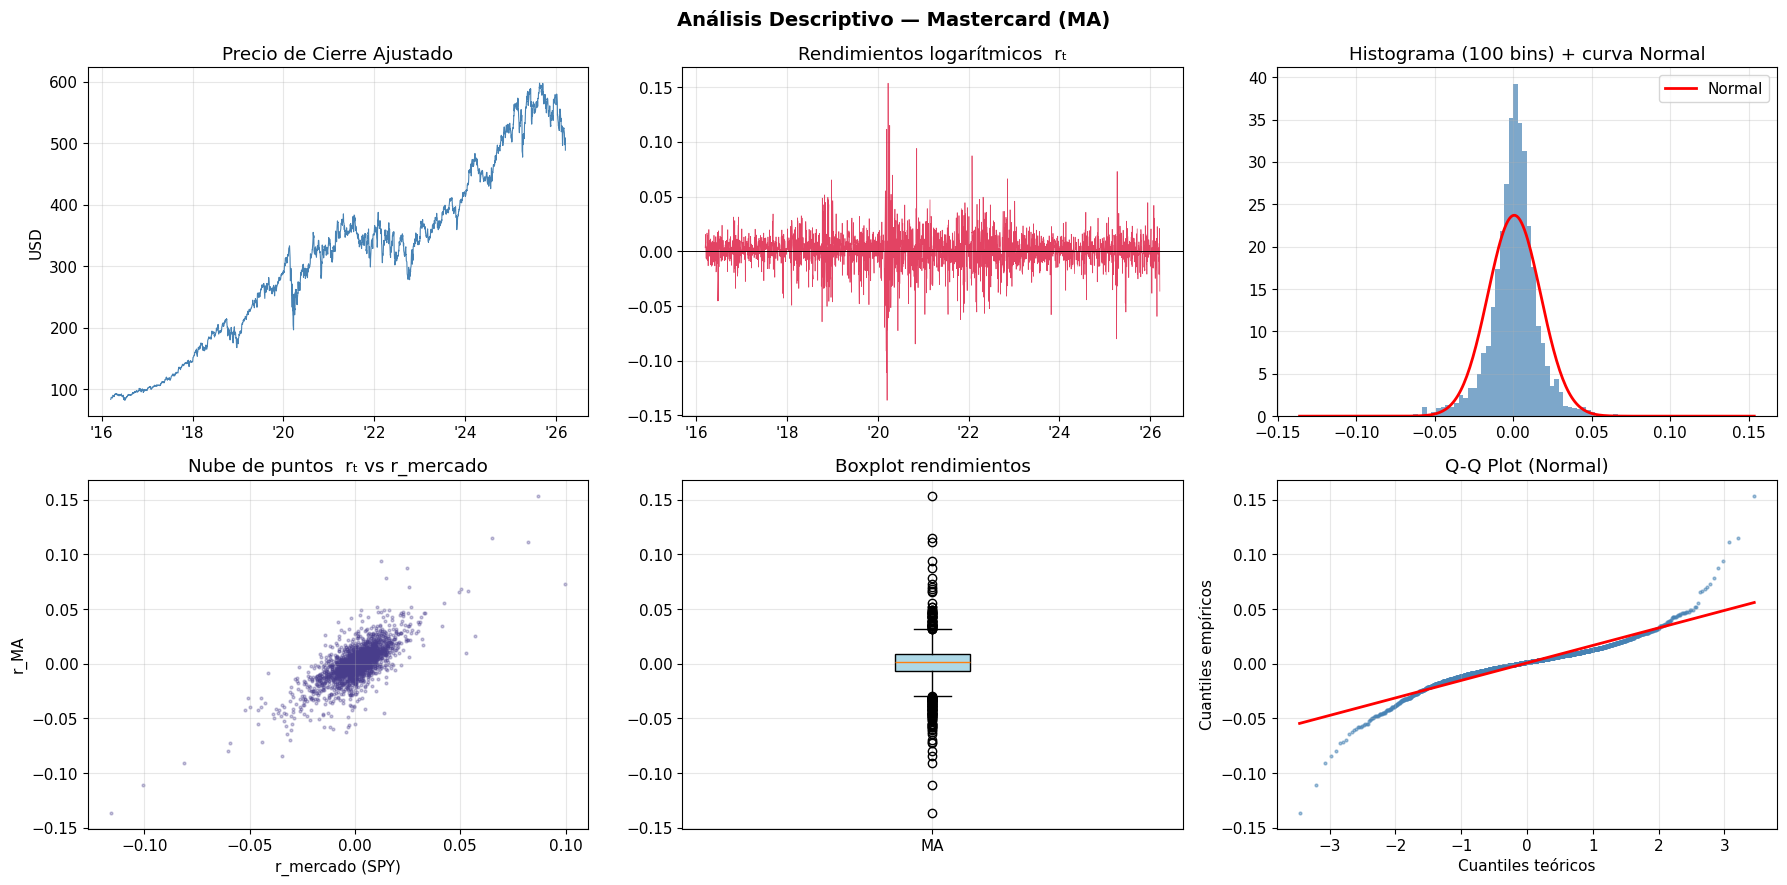

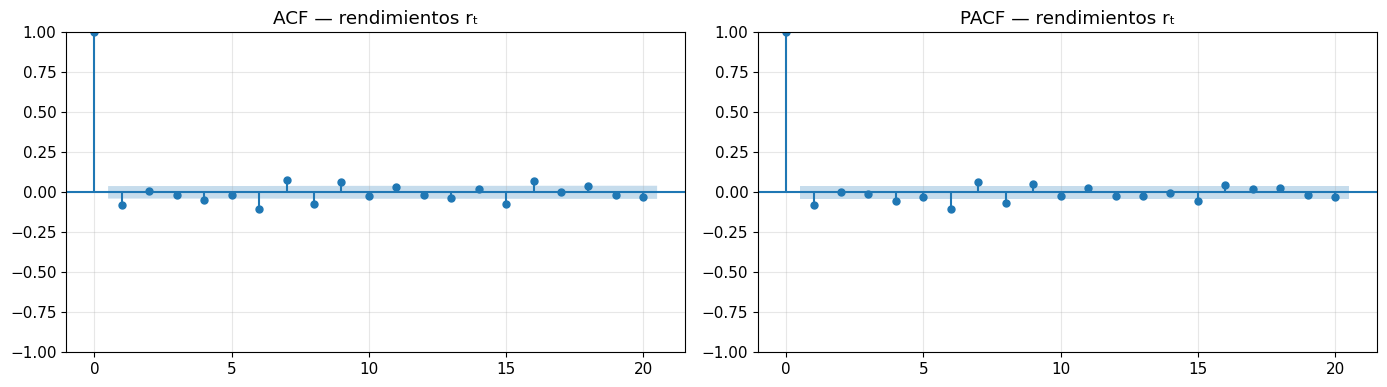

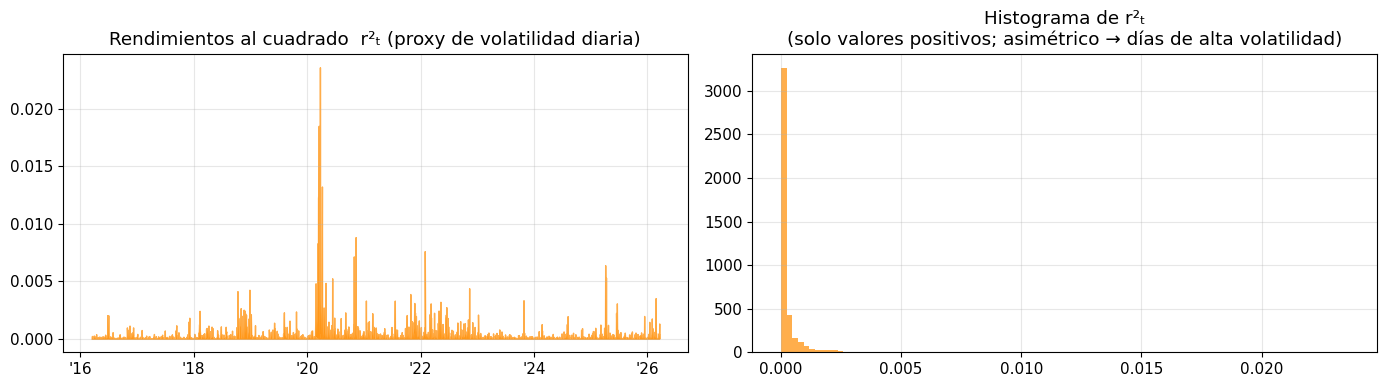


💡 ¿Por qué r²ₜ solo toma valores positivos?
   Porque es el CUADRADO del rendimiento → siempre ≥ 0.
   La mayoría de los días hay baja volatilidad (valores pequeños),
   pero algunos días (crisis, earnings) hay picos enormes.
   La asimetría del histograma refleja exactamente eso.


In [12]:
if not G:
    print('  Ejecuta la Celda 1 primero.')
else:
    df     = G['df']
    r      = df['r']
    r_mkt  = df['r_mkt']
    name   = G['name']
    ticker = G['ticker']

    # ── Estadísticos (equivale al bloque (2) de Gretl) ──────────
    mean_r  = r.mean()
    sd_r    = r.std()
    sk_r    = r.skew()
    ku_r    = r.kurtosis() + 3   # kurtosis exceso → kurtosis total
    jb_stat, jb_pval = stats.jarque_bera(r)
    T       = len(r)

    print(f' ESTADÍSTICOS DESCRIPTIVOS — {name} ({ticker})')
    print('='*55)
    print(f'  Observaciones    : {T}')
    print(f'  Media            : {mean_r:.6f}')
    print(f'  Desv. típica (DT): {sd_r:.6f}')
    print(f'  Asimetría        : {sk_r:.4f}   (0 = simétrica)')
    print(f'  Curtosis         : {ku_r:.4f}   (3 = Normal; >3 = colas pesadas)')
    print(f'  Jarque-Bera      : {jb_stat:.4f}   p-valor: {jb_pval:.2e}')
    print('='*55)
    if jb_pval < 0.05:
        print('  ❌ JB p-valor < 0.05 → RECHAZAMOS normalidad')
        print('     Los rendimientos NO siguen una distribución Normal.')
        print('     → Justifica usar t-Student en los modelos.')
    else:
        print('  ✅ JB p-valor ≥ 0.05 → No rechazamos normalidad')

    print(f'\n  Asimetría {"<0" if sk_r<0 else ">0"}: {"Cola izquierda más pesada (más pérdidas extremas)" if sk_r<0 else "Cola derecha más pesada"}')
    print(f'  Curtosis {ku_r:.2f} {"(>3)" if ku_r>3 else "(≤3)"}: {"Colas más pesadas que la Normal → eventos extremos más frecuentes" if ku_r>3 else "Colas normales"}')

    # ── GRÁFICOS (equivale al bloque (3) de Gretl) ──────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f'Análisis Descriptivo — {name} ({ticker})', fontsize=14, fontweight='bold')

    # 1. Serie temporal de precios
    axes[0,0].plot(df.index, df['price'], color='steelblue', linewidth=0.8)
    axes[0,0].set_title('Precio de Cierre Ajustado')
    axes[0,0].set_ylabel('USD')
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 2. Serie temporal rendimientos (plot_lineas en Gretl)
    axes[0,1].plot(df.index, r, color='crimson', linewidth=0.5, alpha=0.8)
    axes[0,1].axhline(0, color='black', linewidth=0.7)
    axes[0,1].set_title('Rendimientos logarítmicos  rₜ')
    axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 3. Histograma (hist1 en Gretl)
    axes[0,2].hist(r, bins=100, color='steelblue', alpha=0.7, density=True)
    xr = np.linspace(r.min(), r.max(), 300)
    axes[0,2].plot(xr, norm.pdf(xr, mean_r, sd_r), 'r-', lw=2, label='Normal')
    axes[0,2].set_title('Histograma (100 bins) + curva Normal')
    axes[0,2].legend()

    # 4. Nube de puntos (plot_nube en Gretl)
    axes[1,0].scatter(r_mkt, r, alpha=0.3, s=4, color='darkslateblue')
    axes[1,0].set_xlabel(f'r_mercado ({MARKET_TICKER})')
    axes[1,0].set_ylabel(f'r_{ticker}')
    axes[1,0].set_title('Nube de puntos  rₜ vs r_mercado')

    # 5. Boxplot
    axes[1,1].boxplot(r, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
    axes[1,1].set_title('Boxplot rendimientos')
    axes[1,1].set_xticklabels([ticker])

    # 6. Q-Q Plot (qqplot1 en Gretl)
    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    axes[1,2].scatter(osm, osr, s=4, alpha=0.5, color='steelblue')
    axes[1,2].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
    axes[1,2].set_title('Q-Q Plot (Normal)')
    axes[1,2].set_xlabel('Cuantiles teóricos')
    axes[1,2].set_ylabel('Cuantiles empíricos')

    plt.tight_layout()
    plt.show()

    # ── ACF / PACF (corrgm en Gretl) ────────────────────────────
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
    sm.graphics.tsa.plot_acf(r,  lags=20, ax=axes2[0], title='ACF — rendimientos rₜ')
    sm.graphics.tsa.plot_pacf(r, lags=20, ax=axes2[1], title='PACF — rendimientos rₜ', method='ywm')
    plt.tight_layout()
    plt.show()

    # ── Rendimientos al cuadrado (bloque 4 Gretl) ────────────────
    sq_r = r ** 2
    G['sq_r'] = sq_r

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 4))
    axes3[0].fill_between(df.index, sq_r, color='darkorange', alpha=0.7)
    axes3[0].set_title('Rendimientos al cuadrado  r²ₜ (proxy de volatilidad diaria)')
    axes3[0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    axes3[1].hist(sq_r, bins=100, color='darkorange', alpha=0.7, density=True)
    axes3[1].set_title('Histograma de r²ₜ\n(solo valores positivos; asimétrico → días de alta volatilidad)')
    plt.tight_layout()
    plt.show()

    print('\n💡 ¿Por qué r²ₜ solo toma valores positivos?')
    print('   Porque es el CUADRADO del rendimiento → siempre ≥ 0.')
    print('   La mayoría de los días hay baja volatilidad (valores pequeños),')
    print('   pero algunos días (crisis, earnings) hay picos enormes.')
    print('   La asimetría del histograma refleja exactamente eso.')

## Regresión MCO: α, β, riesgo total, sistemático y específico



Estimamos el modelo de mercado:  $r_t = \alpha + \beta \cdot r_{mercado,t} + \varepsilon_t$

| Parámetro | Significado | Interpretación |
|-----------|-------------|----------------|
| **α (alfa)** | Exceso de rendimiento sobre lo esperado | Si ≠0 y significativo: el activo bate al mercado |
| **β (beta)** | Sensibilidad al mercado | β>1 → más volátil que el mercado |

### Descomposición del riesgo:
- **Riesgo Total** = σ(rₜ)  
- **Riesgo Sistemático** = σ(ŷₜ) — no controlable, del entorno macro  
- **Riesgo Específico** = σ(ûₜ) — controlable, propio de la empresa

📋 RESULTADOS MCO — Mastercard (MA) vs SPY
  Parámetro     Estimación     Std. Error    t-stat    p-valor
------------------------------------------------------------
  α (alfa)          0.000100     0.000221    0.4523    0.6511
  β (beta)          1.124412     0.019566   57.4681    0.0000
  R²                0.567592

── Contraste H₀: α = 0  (bilateral)
   t* = 0.4523   |t*| = 0.4523   CV(0.05) = ±1.9609
   p-valor bilateral = 0.6511   → ❌ No rechazamos H₀: α no es significativo (puede ser 0)

── Contraste H₀: β = 1  (bilateral)
   t* = 6.3586   CV bil.(0.05) = ±1.9609
   p-valor bilateral     = 0.0000   → ✅ RECHAZAMOS H₀: β ≠ 1
   p-valor H₁: β > 1    = 0.0000
   p-valor H₁: β < 1    = 1.0000

── Descomposición del Riesgo
  Riesgo TOTAL       (σ rₜ)   : 0.016830  = 1.6830%
  Riesgo SISTEMÁTICO (σ ŷₜ)   : 0.012680  = 1.2680%  (NO controlable, macro)
  Riesgo ESPECÍFICO  (σ ûₜ)   : 0.011067  = 1.1067%  (controlable, empresa)
  R² (% riesgo explicado)      : 56.76%
  💡 β=1.1244 > 1 → El 

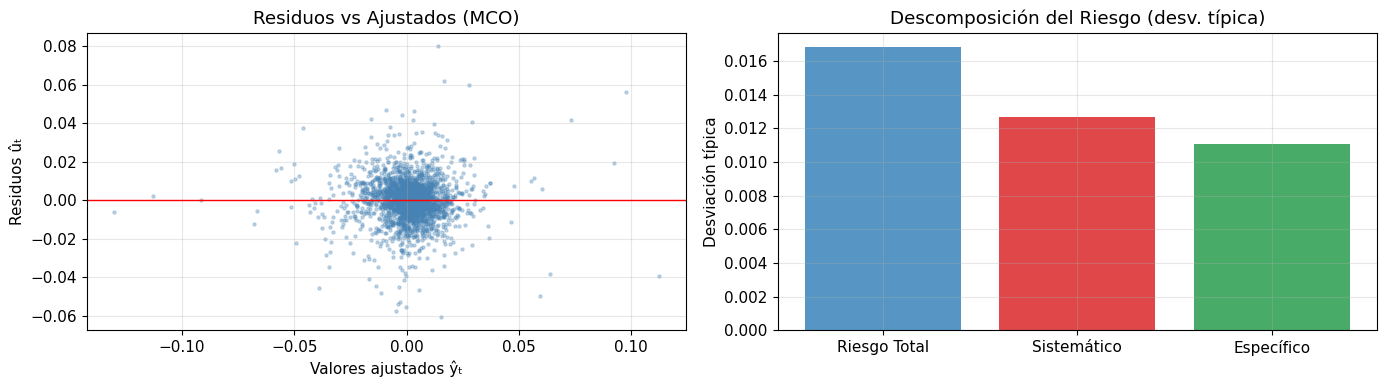

In [13]:
if not G or 'sq_r' not in G:
    print('⚠️  Ejecuta la Celda 2 primero.')
else:
    df    = G['df']
    r     = df['r']
    r_mkt = df['r_mkt']
    name  = G['name']
    T     = len(r)

    # ── MCO (equivale a `ols r_my_v 0 r_market` en Gretl) ──────
    X     = sm.add_constant(r_mkt)
    MCO   = sm.OLS(r, X).fit()

    alpha_coef = MCO.params['const']
    beta_coef  = MCO.params['r_mkt']
    se_alpha   = MCO.bse['const']
    se_beta    = MCO.bse['r_mkt']

    # ── Contrastes H0: alpha=0 (Gretl línea 52-65) ──────────────
    dof_MCO = T - 2
    t_alpha = (alpha_coef - 0) / se_alpha
    pv_alpha_bi = 2 * t_dist.sf(abs(t_alpha), dof_MCO)
    CV_bil005   = t_dist.ppf(0.975, dof_MCO)

    # ── Contraste H0: beta=1 (Gretl línea 68-80) ────────────────
    t_beta  = (beta_coef - 1) / se_beta
    pv_beta_bi    = 2 * t_dist.sf(abs(t_beta), dof_MCO)
    pv_beta_mayor = t_dist.sf(t_beta, dof_MCO)         # H1: beta > 1
    pv_beta_menor = t_dist.cdf(t_beta, dof_MCO)        # H1: beta < 1
    CV_uni_mayor  = t_dist.ppf(0.95, dof_MCO)
    CV_uni_menor  = t_dist.ppf(0.05, dof_MCO)

    # ── Riesgos (Gretl línea 88-100) ────────────────────────────
    yhat   = MCO.fittedvalues
    resid  = MCO.resid
    R_total = r.std()
    R_sist  = yhat.std()
    R_espc  = resid.std()
    R2      = MCO.rsquared

    G['MCO']    = MCO
    G['alpha']  = alpha_coef
    G['beta']   = beta_coef

    # ── RESULTADOS ───────────────────────────────────────────────
    print(f'📋 RESULTADOS MCO — {name} ({G["ticker"]}) vs {MARKET_TICKER}')
    print('='*60)
    print(f'  Parámetro     Estimación     Std. Error    t-stat    p-valor')
    print('-'*60)
    print(f'  α (alfa)      {alpha_coef:>12.6f}   {se_alpha:>10.6f}  {t_alpha:>8.4f}  {pv_alpha_bi:>8.4f}')
    print(f'  β (beta)      {beta_coef:>12.6f}   {se_beta:>10.6f}  {MCO.tvalues["r_mkt"]:>8.4f}  {MCO.pvalues["r_mkt"]:>8.4f}')
    print(f'  R²            {R2:>12.6f}')
    print('='*60)

    print(f'\n── Contraste H₀: α = 0  (bilateral)')
    print(f'   t* = {t_alpha:.4f}   |t*| = {abs(t_alpha):.4f}   CV(0.05) = ±{CV_bil005:.4f}')
    print(f'   p-valor bilateral = {pv_alpha_bi:.4f}', end='   ')
    if pv_alpha_bi < 0.05:
        print('→ ✅ RECHAZAMOS H₀: α significativamente distinto de 0')
    else:
        print('→ ❌ No rechazamos H₀: α no es significativo (puede ser 0)')

    print(f'\n── Contraste H₀: β = 1  (bilateral)')
    print(f'   t* = {t_beta:.4f}   CV bil.(0.05) = ±{CV_bil005:.4f}')
    print(f'   p-valor bilateral     = {pv_beta_bi:.4f}', end='   ')
    if pv_beta_bi < 0.05:
        print('→ ✅ RECHAZAMOS H₀: β ≠ 1')
    else:
        print('→ ❌ No rechazamos H₀: β = 1 es plausible')
    print(f'   p-valor H₁: β > 1    = {pv_beta_mayor:.4f}')
    print(f'   p-valor H₁: β < 1    = {pv_beta_menor:.4f}')

    print(f'\n── Descomposición del Riesgo')
    print('='*55)
    print(f'  Riesgo TOTAL       (σ rₜ)   : {R_total:.6f}  = {R_total*100:.4f}%')
    print(f'  Riesgo SISTEMÁTICO (σ ŷₜ)   : {R_sist:.6f}  = {R_sist*100:.4f}%  (NO controlable, macro)')
    print(f'  Riesgo ESPECÍFICO  (σ ûₜ)   : {R_espc:.6f}  = {R_espc*100:.4f}%  (controlable, empresa)')
    print(f'  R² (% riesgo explicado)      : {R2*100:.2f}%')
    print('='*55)

    if beta_coef > 1:
        print(f'  💡 β={beta_coef:.4f} > 1 → El activo es MÁS volátil que el mercado (activo agresivo)')
    elif beta_coef < 1:
        print(f'  💡 β={beta_coef:.4f} < 1 → El activo es MENOS volátil que el mercado (activo defensivo)')
    else:
        print(f'  💡 β={beta_coef:.4f} ≈ 1 → El activo se mueve igual que el mercado')

    # ── Gráfico residuos vs fitted ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(yhat, resid, alpha=0.3, s=5, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('Valores ajustados ŷₜ')
    axes[0].set_ylabel('Residuos ûₜ')
    axes[0].set_title('Residuos vs Ajustados (MCO)')

    axes[1].bar(['Riesgo Total', 'Sistemático', 'Específico'],
                [R_total, R_sist, R_espc],
                color=['#2c7bb6', '#d7191c', '#1a9641'], alpha=0.8)
    axes[1].set_title('Descomposición del Riesgo (desv. típica)')
    axes[1].set_ylabel('Desviación típica')
    plt.tight_layout()
    plt.show()

---
# Modelos de Volatilidad Condicional

---

## r², MM5 y RiskMetrics RM094


### ¿Qué es λ (lambda) en RiskMetrics?

> **λ = 0.94** es el **parámetro de persistencia** ("memoria") del modelo.
> - El **94%** de la volatilidad futura depende de la volatilidad pasada
> - Solo el **6%** viene del shock de ayer (r²ₜ)
> - **Mayor λ → mayor memoria → el modelo tarda más en "olvidar" los shocks**
> - La fórmula recursiva: $\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,r_{t-1}^2$

### Comparación de los tres modelos:
| Modelo | Memoria | Velocidad de reacción | Suavizado |
|--------|---------|----------------------|----------|
| **r²** | Ninguna | Máxima ("nervioso") | Ninguno |
| **MM5** | 5 días igual peso | Media | Moderado |
| **RM094** | Infinita (decayendo) | Gradual | Alto |

> **La media aritmética de MM5 y RM094 es una aproximación a la varianza incondicional.**

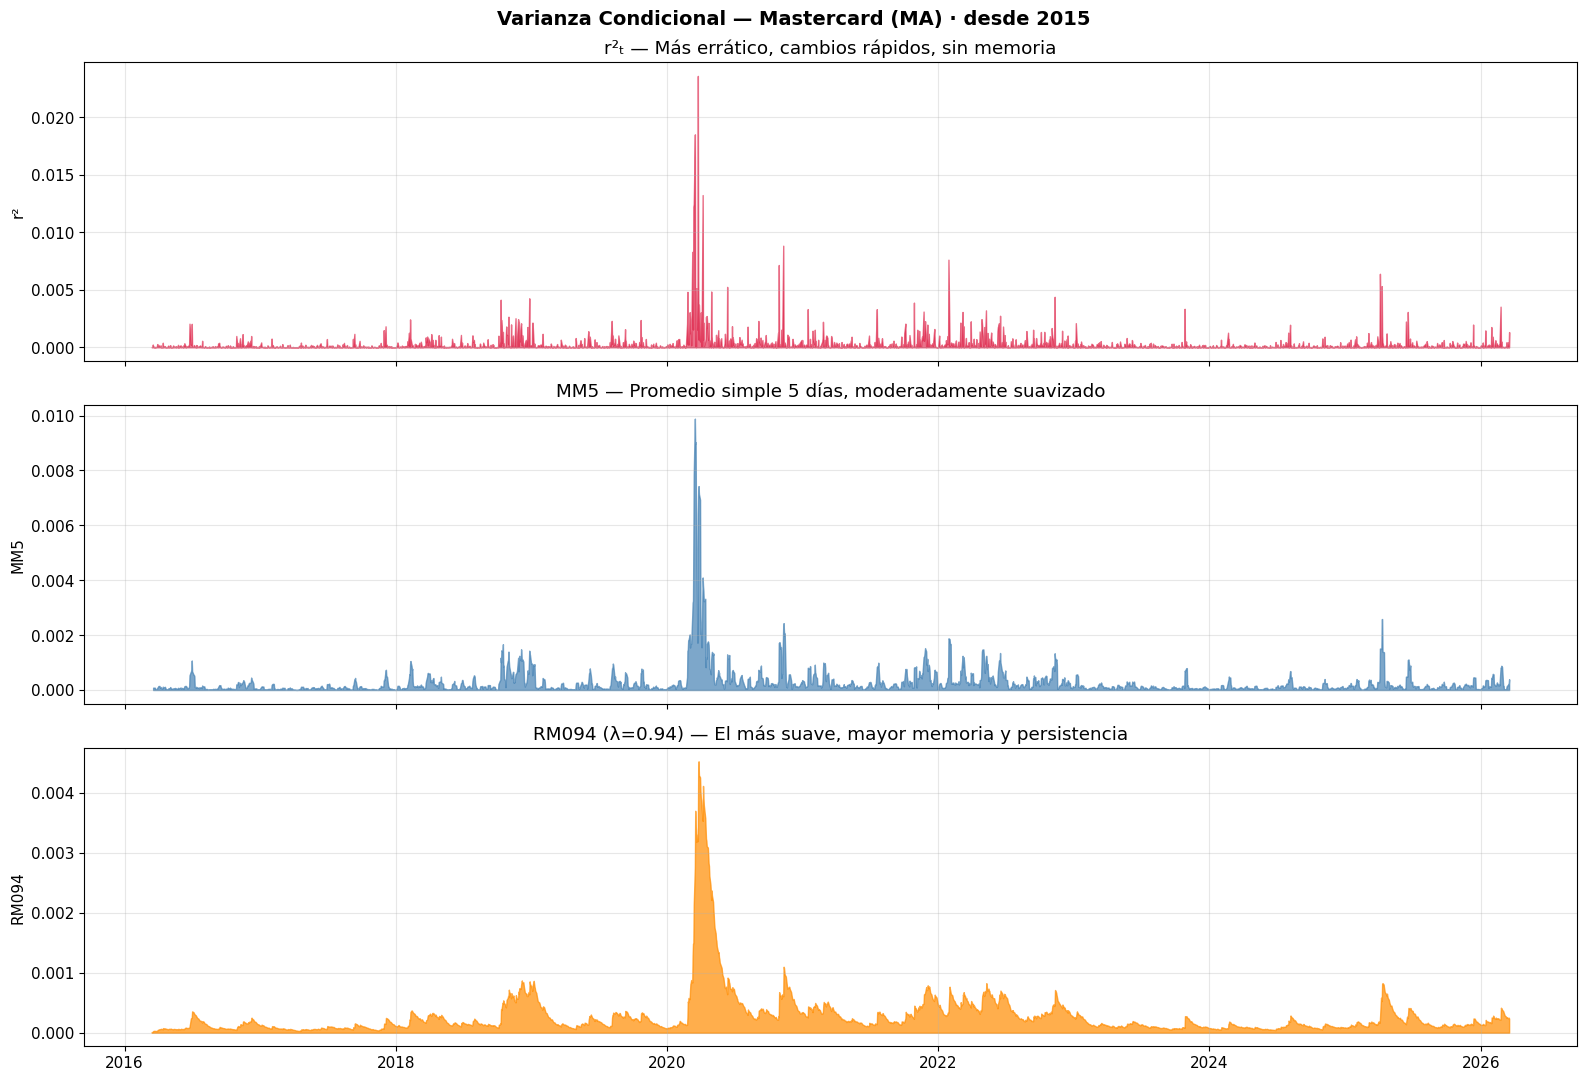

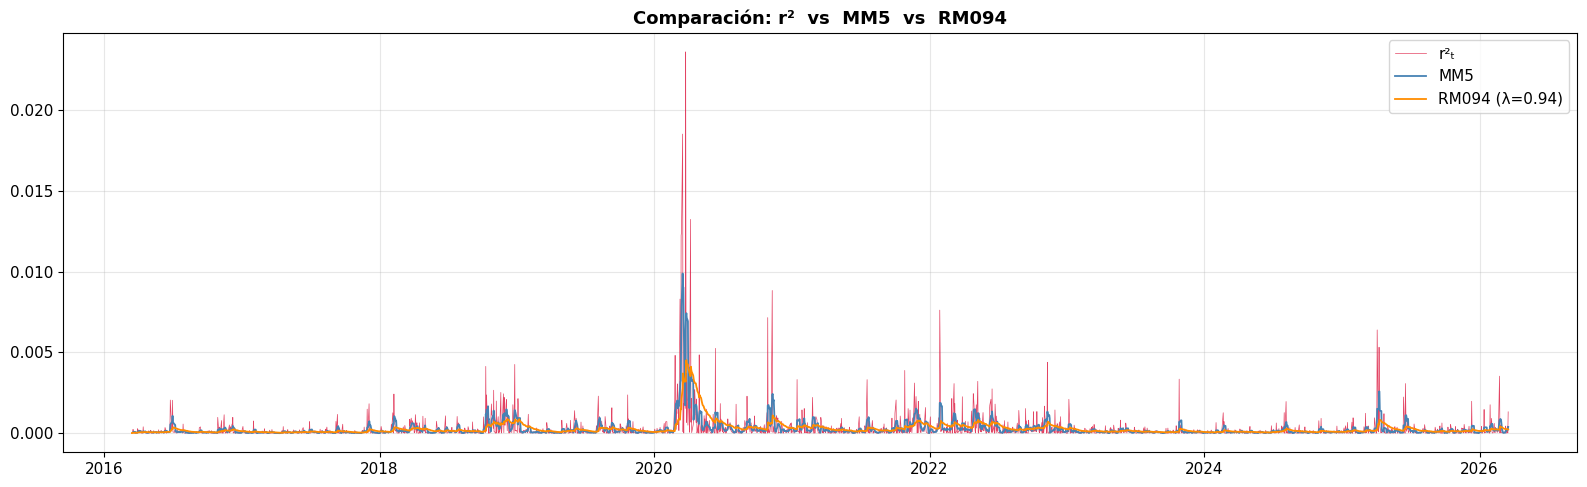


📊 TABLA: Medias de las medidas de volatilidad
  (La media de MM5 y RM094 ≈ varianza incondicional)
  Media r²           (más alto, sin filtro) : 0.00028364
  Media MM5          (5 días, moderado)     : 0.00028355
  Media RM094        (λ=0.94, más suave)    : 0.00028171
  Varianza incond.   (sd(r)²)               : 0.00028326
  Vol. incond.       (sd(r))                : 0.01683022

💡 INTERPRETACIÓN:
  • r²: promedio MÁS ALTO → incluye todos los picos sin ningún filtro
  • MM5: suaviza extremos → promedio ligeramente inferior
  • RM094: mayor memoria y persistencia → promedio MÁS BAJO
  • Orden de persistencia: r² < MM5 < RM094
  • Un promedio alto indica alta incertidumbre general en el período
  • GARCH-GJR: α ≈ (1-λ),  β ≈ λ  (analogía con RiskMetrics)


In [14]:
if not G or 'sq_r' not in G:
    print('⚠️  Ejecuta las celdas anteriores primero.')
else:
    df   = G['df']
    r    = df['r']
    sq_r = G['sq_r']
    name = G['name']
    ticker = G['ticker']

    # ── MM5: media móvil simple 5 días ───────────────────────────
    # Gretl: movavg(sq_r_my_v, 5, 0)  → ventana 5, tipo simple
    MM5 = sq_r.rolling(window=5).mean()

    # ── RM094: suavizado exponencial (EWMA) ──────────────────────
    # Gretl: movavg(sq_r_my_v, 0.06, 1) → parámetro es (1-λ)=0.06
    # Fórmula: σ²ₜ = λ·σ²ₜ₋₁ + (1-λ)·r²ₜ₋₁
    lam  = 0.94
    rm   = np.zeros(len(sq_r))
    rm[0] = sq_r.iloc[0]
    for i in range(1, len(sq_r)):
        rm[i] = lam * rm[i-1] + (1 - lam) * sq_r.iloc[i-1]
    RM094 = pd.Series(rm, index=sq_r.index)

    df['sq_r']  = sq_r
    df['MM5']   = MM5
    df['RM094'] = RM094
    G['df']     = df

    # ── GRÁFICO comparativo (equivale al gnuplot de Gretl línea 140) ─
    # Subperiodo 2015–hoy como en Gretl: smpl 2015-01-01 ...
    mask = df.index >= '2015-01-01'

    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
    fig.suptitle(f'Varianza Condicional — {name} ({ticker}) · desde 2015',
                 fontsize=14, fontweight='bold')

    axes[0].fill_between(df.index[mask], sq_r[mask], color='crimson', alpha=0.6)
    axes[0].set_title('r²ₜ — Más errático, cambios rápidos, sin memoria')
    axes[0].set_ylabel('r²')

    axes[1].fill_between(df.index[mask], MM5[mask], color='steelblue', alpha=0.7)
    axes[1].set_title('MM5 — Promedio simple 5 días, moderadamente suavizado')
    axes[1].set_ylabel('MM5')

    axes[2].fill_between(df.index[mask], RM094[mask], color='darkorange', alpha=0.7)
    axes[2].set_title('RM094 (λ=0.94) — El más suave, mayor memoria y persistencia')
    axes[2].set_ylabel('RM094')
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    # ── Gráfico superpuesto ──────────────────────────────────────
    fig2, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df.index[mask], sq_r[mask],   color='crimson',   lw=0.5, alpha=0.8, label='r²ₜ')
    ax.plot(df.index[mask], MM5[mask],    color='steelblue', lw=1.3, label='MM5')
    ax.plot(df.index[mask], RM094[mask],  color='darkorange',lw=1.3, label='RM094 (λ=0.94)')
    ax.set_title('Comparación: r²  vs  MM5  vs  RM094', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    # ── Medias (Gretl comentario L151/L160) ──────────────────────
    mean_sq_r = sq_r.mean()
    mean_MM5  = MM5.dropna().mean()
    mean_RM   = RM094.mean()
    Incond_std = r.std()     # equivale a `Incond_std = sd(r_my_v)` en Gretl

    print('\n📊 TABLA: Medias de las medidas de volatilidad')
    print('  (La media de MM5 y RM094 ≈ varianza incondicional)')
    print('='*60)
    print(f'  Media r²           (más alto, sin filtro) : {mean_sq_r:.8f}')
    print(f'  Media MM5          (5 días, moderado)     : {mean_MM5:.8f}')
    print(f'  Media RM094        (λ=0.94, más suave)    : {mean_RM:.8f}')
    print(f'  Varianza incond.   (sd(r)²)               : {Incond_std**2:.8f}')
    print(f'  Vol. incond.       (sd(r))                : {Incond_std:.8f}')
    print('='*60)

    print('\n💡 INTERPRETACIÓN:')
    print(f'  • r²: promedio MÁS ALTO → incluye todos los picos sin ningún filtro')
    print(f'  • MM5: suaviza extremos → promedio ligeramente inferior')
    print(f'  • RM094: mayor memoria y persistencia → promedio MÁS BAJO')
    print(f'  • Orden de persistencia: r² < MM5 < RM094')
    print(f'  • Un promedio alto indica alta incertidumbre general en el período')
    print(f'  • GARCH-GJR: α ≈ (1-λ),  β ≈ λ  (analogía con RiskMetrics)')

##  Estimación GARCH-GJR (t-Student y Normal) + Tabla 1



### Modelo GJR-GARCH:
$$\sigma^2_{t+1} = \underbrace{\omega}_{\text{base}} + \underbrace{\alpha\,r_t^2}_{\text{noticias}} + \underbrace{\gamma\,r_t^2\,\mathbf{1}(r_t<0)}_{\text{efecto asimétrico}} + \underbrace{\beta\,\sigma_t^2}_{\text{persistencia}}$$

| Parámetro | Significado | Clave |
|-----------|-------------|-------|
| **ω (omega)** | Volatilidad base | Pequeño pero significativo |
| **α (alpha)** | Impacto de shocks | Noticias positivas |
| **γ (gamma)** | Efecto asimétrico | Si >0: malas noticias impactan MÁS |
| **β (beta)** | Persistencia | Cerca de 1 → volatilidad duradera |
| **V₀** | Volatilidad incondicional | $\omega / (1-\alpha-\gamma/2-\beta)$ |
| **dof** | Grados de libertad t-Student | Pequeño → colas muy pesadas |

>

⏳ Estimando GJR-GARCH con distribución t-Student...
✅ t-Student listo.
⏳ Estimando GJR-GARCH con distribución Normal...
✅ Normal lista.

📋 TABLA 1 — Estimación modelos GARCH-GJR
                       Omega       Alpha       Gamma      Beta        V0     dof        LLik             AIC             BIC
----------------------------------------------------------------------------------------------------
t-Student         0.00000815    0.061937    0.118406  0.851515  0.000298 4.55638 -4328.50305      8669.00610      8703.99342
Normal            0.00001049    0.071967    0.126148  0.825766  0.000268    —    -4435.50319      8881.00638      8910.16248

── P-valores ──
                  p(omega)    p(alpha)    p(gamma)     p(beta)
-------------------------------------------------------
t-Student           0.0064      0.0128      0.0021      0.0000
Normal              0.0021      0.0077      0.0061      0.0000

── Z-estadísticos (|z|>2 → significativo) ──
t-Student       z_ω=  2.729  z_α=  2.4

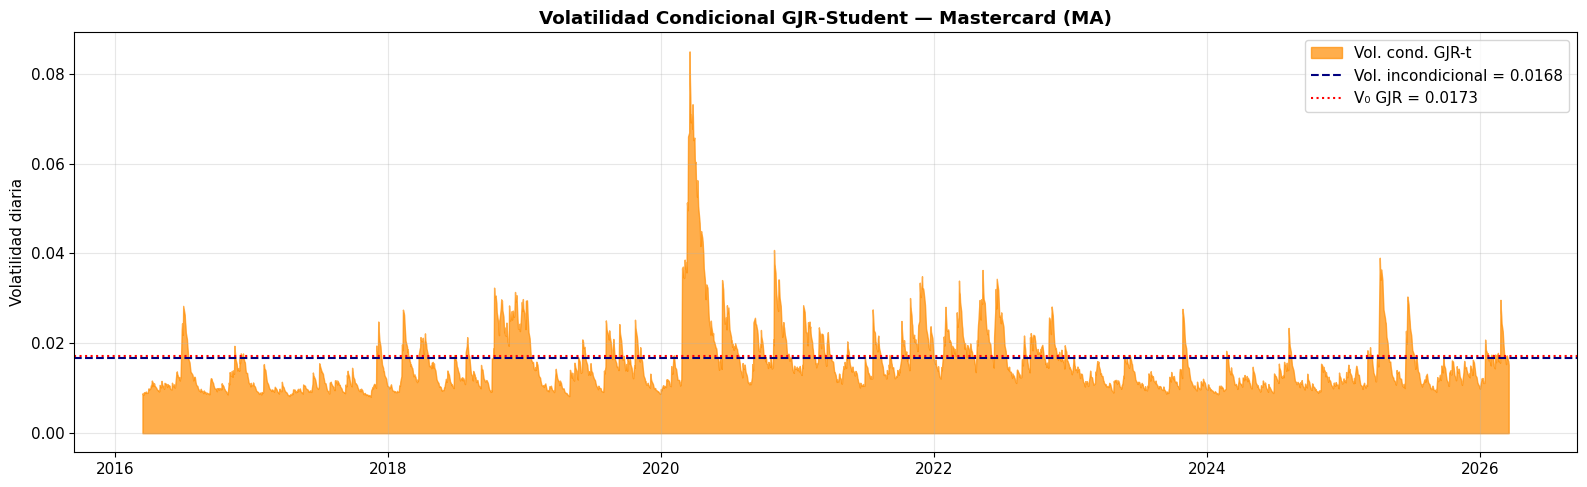

In [15]:
if not G or 'MM5' not in G['df'].columns:
    print('⚠️  Ejecuta la Celda 4 primero.')
else:
    df     = G['df']
    r      = df['r']
    name   = G['name']
    ticker = G['ticker']

    # arch espera rendimientos en %; escalamos ×100 para estabilidad numérica
    # (equivale a trabajar con r_my_v directamente en Gretl que ya está en unidades)
    r100 = r * 100

    # ── GJR-GARCH t-Student ──────────────────────────────────────
    # Gretl: GUI_gig(r_my_v, 3, 1, 1, null, 1, 0, null, 1, 0, 1)
    # posición 2=3 → GJR;  posición 9=1 → t-Student
    print('⏳ Estimando GJR-GARCH con distribución t-Student...')
    mod_t = arch_model(r100, vol='GARCH', p=1, o=1, q=1, dist='t', mean='Constant')
    res_t = mod_t.fit(disp='off', show_warning=False)
    print('✅ t-Student listo.')

    # ── GJR-GARCH Normal ─────────────────────────────────────────
    # posición 9=0 → Gaussian
    print('⏳ Estimando GJR-GARCH con distribución Normal...')
    mod_n = arch_model(r100, vol='GARCH', p=1, o=1, q=1, dist='normal', mean='Constant')
    res_n = mod_n.fit(disp='off', show_warning=False)
    print('✅ Normal lista.')

    G['res_t'] = res_t
    G['res_n'] = res_n

    # ── Extraer parámetros ───────────────────────────────────────
    def extract(res):
        p  = res.params
        pv = res.pvalues
        zv = res.tvalues  # arch llama tvalues a los z-stats
        # omega viene escalado ×10000 (porque escalamos ×100 los retornos)
        omega = p['omega'] / 10000
        alpha = p['alpha[1]']
        gamma = p['gamma[1]']
        beta  = p['beta[1]']
        denom = 1 - alpha - gamma/2 - beta
        V0    = (omega / denom) if denom > 0 else np.nan
        dof   = p.get('nu', np.nan)
        return {
            'omega': omega, 'alpha': alpha, 'gamma': gamma, 'beta': beta,
            'V0': V0, 'dof': dof,
            'llik': res.loglikelihood, 'aic': res.aic, 'bic': res.bic,
            'pv_o': pv['omega'], 'pv_a': pv['alpha[1]'],
            'pv_g': pv['gamma[1]'], 'pv_b': pv['beta[1]'],
            'z_o': zv['omega'],  'z_a': zv['alpha[1]'],
            'z_g': zv['gamma[1]'], 'z_b': zv['beta[1]'],
        }

    pt = extract(res_t)
    pn = extract(res_n)
    G['pt'] = pt
    G['pn'] = pn

    # ── TABLA 1 ──────────────────────────────────────────────────
    print()
    print('📋 TABLA 1 — Estimación modelos GARCH-GJR')
    print('='*100)
    hdr = f'{"":<14}{"Omega":>14}{"Alpha":>12}{"Gamma":>12}{"Beta":>10}{"V0":>10}{"dof":>8}{"LLik":>12}{"AIC":>16}{"BIC":>16}'
    print(hdr)
    print('-'*100)
    def print_row(label, p):
        dof_s = f"{p['dof']:.5f}" if not np.isnan(p['dof']) else '   —   '
        print(f"{label:<14}{p['omega']:>14.8f}{p['alpha']:>12.6f}{p['gamma']:>12.6f}"
              f"{p['beta']:>10.6f}{p['V0']:>10.6f}{dof_s:>8}"
              f"{p['llik']:>12.5f}{p['aic']:>16.5f}{p['bic']:>16.5f}")
    print_row('t-Student', pt)
    print_row('Normal',    pn)

    print('\n── P-valores ──')
    hdr2 = f'{"":<14}{"p(omega)":>12}{"p(alpha)":>12}{"p(gamma)":>12}{"p(beta)":>12}'
    print(hdr2)
    print('-'*55)
    for lab, p in [('t-Student', pt), ('Normal', pn)]:
        print(f"{lab:<14}{p['pv_o']:>12.4f}{p['pv_a']:>12.4f}{p['pv_g']:>12.4f}{p['pv_b']:>12.4f}")

    print('\n── Z-estadísticos (|z|>2 → significativo) ──')
    for lab, p in [('t-Student', pt), ('Normal', pn)]:
        print(f"{lab:<14}  z_ω={p['z_o']:>7.3f}  z_α={p['z_a']:>7.3f}  z_γ={p['z_g']:>7.3f}  z_β={p['z_b']:>7.3f}")

    print('\n💡 INTERPRETACIÓN:')
    print(f'  • Persistencia t-Student: α+γ/2+β = {pt["alpha"]+pt["gamma"]/2+pt["beta"]:.6f}')
    print(f'  • Persistencia Normal:    α+γ/2+β = {pn["alpha"]+pn["gamma"]/2+pn["beta"]:.6f}')
    print(f'  • Cuanto más cerca de 1, mayor persistencia → shocks tardan más en disiparse')
    print(f'  • γ={pt["gamma"]:.6f} > 0 → efecto apalancamiento: malas noticias impactan MÁS la vol.')
    print(f'  • V₀={pt["V0"]:.6f} → volatilidad incondicional (nivel de largo plazo) del modelo GJR-t')
    print(f'  • dof={pt["dof"]:.4f} → grados de libertad t-Student (menor = colas más pesadas)')

    # ── Criterios de información ─────────────────────────────────
    print('\n📋 CRITERIOS DE SELECCIÓN (Llik, AIC, BIC):')
    print('='*55)
    print(f'  {"":<12}{"t-Student":>16}{"Normal":>16}')
    print('-'*45)
    print(f'  {"Llik":<12}{pt["llik"]:>16.5f}{pn["llik"]:>16.5f}  ← Mayor = Mejor')
    print(f'  {"AIC":<12}{pt["aic"]:>16.5f}{pn["aic"]:>16.5f}  ← Menor = Mejor')
    print(f'  {"BIC":<12}{pt["bic"]:>16.5f}{pn["bic"]:>16.5f}  ← Menor = Mejor')
    print('='*55)
    mejor = 't-Student' if pt['aic'] < pn['aic'] else 'Normal'
    print(f'  ✅ Modelo preferido: {mejor} (mayor Llik, menor AIC y BIC)')
    print(f'  💡 La t-Student captura mejor las colas pesadas de los rendimientos financieros')

    # ── Volatilidad condicional GJR ──────────────────────────────
    # Equivale a: vol_GJR_t = (model_GJR_t.h)^0.5 en Gretl
    vol_cond_t_scaled = res_t.conditional_volatility   # en unidades × 100
    vol_cond_t        = vol_cond_t_scaled / 100         # escala original
    var_cond_t        = vol_cond_t ** 2
    idx_cv            = df.index[-len(vol_cond_t):]

    G['vol_cond_t'] = pd.Series(vol_cond_t, index=idx_cv)
    G['var_cond_t'] = pd.Series(var_cond_t, index=idx_cv)

    # ── TABLA 2 ──────────────────────────────────────────────────
    Incond_std = r.std()
    last_RM    = df['RM094'].iloc[-1]
    last_var_gjr = var_cond_t[-1]
    V0_gjr     = pt['V0']

    print('\n📋 TABLA 2 — Estimación de la Volatilidad como Medida de Riesgo')
    print('  (última estimación disponible para las condicionales)')
    print('='*65)
    rows2 = [
        ('1. Raíz cuadrada de r²  (último día)',   df['sq_r'].iloc[-1],     np.sqrt(df['sq_r'].iloc[-1])),
        ('2. Vol. Incondicional (sd histórica)',     Incond_std**2,           Incond_std),
        ('3. Var. cond. RM094  (último día)',        last_RM,                 np.sqrt(last_RM)),
        ('4. Media RM094  (período completo)',        df['RM094'].mean(),      np.sqrt(df['RM094'].mean())),
        ('5. Var. cond. GJR-Stud. (último día)',    last_var_gjr,            np.sqrt(last_var_gjr)),
        ('6. Media var. cond. GJR-Stud.',           var_cond_t.mean(),       np.sqrt(var_cond_t.mean())),
        ('7. V0 — Vol. incond. GJR-Student',        V0_gjr,                  np.sqrt(V0_gjr)),
    ]
    print(f'  {"":<42} {"Varianza":>10} {"Volatilidad":>12}')
    print('-'*65)
    for lab, va, vo in rows2:
        print(f'  {lab:<42} {va:>10.6f} {vo:>12.6f}')
    print('='*65)

    # ── Gráfico volatilidad condicional ──────────────────────────
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.fill_between(idx_cv, vol_cond_t, color='darkorange', alpha=0.7, label='Vol. cond. GJR-t')
    ax.axhline(Incond_std, color='navy', lw=1.5, ls='--', label=f'Vol. incondicional = {Incond_std:.4f}')
    ax.axhline(np.sqrt(V0_gjr), color='red', lw=1.5, ls=':', label=f'V₀ GJR = {np.sqrt(V0_gjr):.4f}')
    ax.set_title(f'Volatilidad Condicional GJR-Student — {name} ({ticker})', fontweight='bold')
    ax.set_ylabel('Volatilidad diaria')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

---
# Cálculo de VaR y ES

---

## VaR y ES: Histórico, Paramétrico (N y t) y Monte Carlo

### ¿Qué es el VaR y el ES?
- **VaR(τ)**: Pérdida máxima que **no se supera** con probabilidad (1-τ). Al 1%: con 99% de confianza.
- **ES(τ)**: Pérdida **esperada** cuando SÍ se supera el VaR. Siempre ES > VaR (más conservador).




**Histórico:** $VaR_H = -Q_{\tau}(r_t)$,   $ES_H = -E[r_t | r_t \le -VaR_H]$

**Paramétrico Normal:** $VaR_N = -\mu - \sigma\,z_{\tau}$,   $ES_N = -\mu + \sigma\,\frac{\phi(z_{\tau})}{\tau}$

**Paramétrico t-Student (dinámico con GJR):**
$$VaR_t = -\mu_R - \sigma_R\sqrt{\frac{d-2}{d}}\,t_d^{-1}(\tau)$$
$$ES_t = -\mu_R + \sigma_R\,\frac{1}{\tau}\sqrt{\frac{d-2}{d}}\cdot\frac{1}{d-1}\left(d + t_d^{-1}(\tau)^2\right)f_d\left(t_d^{-1}(\tau)\right)$$

**Monte Carlo:** simulamos 100.000 escenarios de $r_{t+1} = \sigma_t^{GJR}\cdot z$, con $z \sim t_{dof}$

📋 TABLA 3 — VaR y ES al 1% y 2.5%
                                      τ=1%        τ=2.5%
----------------------------------------------------------
  1. VaR Histórico               0.0485745     0.0358616
  2. ES Histórico                0.0660027     0.0520730
  3. VaR Paramétrico (N)         0.0384512     0.0322849
  4. ES Normal                   0.0441544     0.0386440
  5. VaR t-Student               0.0435008     0.0326765
  6. ES t-Student                0.0589264     0.0458659
  7. VaR Monte Carlo             0.0529249     0.0403318
  8. ES Monte Carlo              0.0718694     0.0561378

💡 INTERPRETACIÓN:
  • VaR 1% Histórico: 0.0486 → pérdida máxima con 99% confianza
  • ES 1%  Histórico: 0.0660 → pérdida media si se supera el VaR
  • ES > VaR siempre (ES mide el PROMEDIO de las pérdidas extremas)
  • Monte Carlo es más conservador: simula escenarios con la vol. condicional GJR actual
  • VaR 1% puede ser MENOR que ES 2.5% → normal, miden cosas distintas
  • t-Student > No

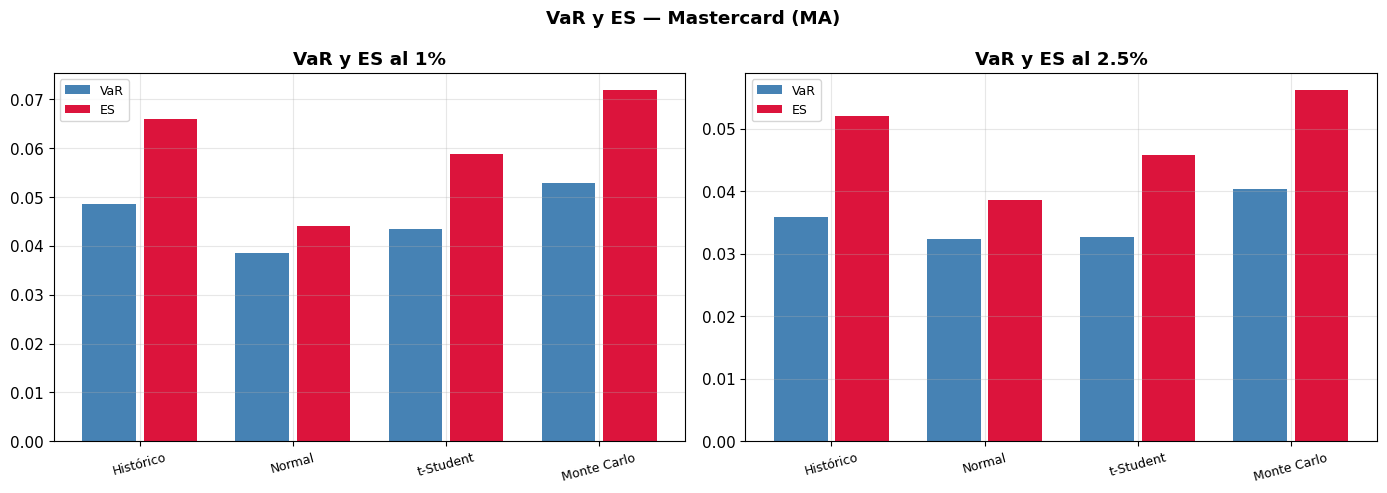

In [16]:
if 'pt' not in G:
    print('⚠️  Ejecuta la Celda 5 primero.')
else:
    df      = G['df']
    r       = df['r']
    pt      = G['pt']
    res_t   = G['res_t']
    mu_r    = r.mean()
    sd_r    = r.std()
    dof     = pt['dof'] if not np.isnan(pt['dof']) else 5.0
    # Última volatilidad condicional GJR (equivale a vol_GJR_t[nobs_last])
    last_vol_gjr = G['vol_cond_t'].iloc[-1]

    G['mu_r'] = mu_r
    G['sd_r'] = sd_r
    G['dof']  = dof

    taus   = [0.01, 0.025]
    RES    = {}

    for tau in taus:
        # ── HISTÓRICO ─────────────────────────────────────────────
        # Gretl: VaR_H_001 = - quantile(r_my_v, tau)
        VaR_H = -np.percentile(r, tau*100)
        # Gretl: smpl r_my_v <= -VaR_H_001 --restrict  → ES_H = -mean(r_my_v)
        mask_h = r <= -VaR_H
        ES_H   = -r[mask_h].mean()

        # ── PARAMÉTRICO NORMAL ────────────────────────────────────
        # Gretl: VaR_P_G_tau = - mean(r) - sd(r) * invcdf(n, tau)
        z_tau   = norm.ppf(tau)
        VaR_PN  = -mu_r - sd_r * z_tau
        # Gretl: ES_P_G_tau = - mean(r) + sd(r) * 1/tau * pdf(n, invcdf(n, tau))
        ES_PN   = -mu_r + sd_r * (1/tau) * norm.pdf(z_tau)

        # ── PARAMÉTRICO t-STUDENT (con sigma condicional GJR) ─────
        # Gretl: VaR_P_t_tau = - mean(r) - sd(r) * ((dof-2)/dof)^0.5 * invcdf(t,dof,tau)
        # IMPORTANTE: usa sd(r) = volatilidad histórica para el VaR estático
        # y vol_GJR_t[last] para el dinámico
        t_tau   = t_dist.ppf(tau, df=dof)
        scale   = sd_r * np.sqrt((dof-2)/dof)    # estático
        VaR_Pt  = -mu_r - scale * t_tau
        # Gretl: ES_P_t_tau = - mean(r) + sd(r) * 1/tau * ((dof-2)/dof)^0.5
        #                     * 1/(dof-1) * (dof + invcdf(t,dof,tau)^2) * pdf(t,dof,invcdf(t,dof,tau))
        fd_t    = t_dist.pdf(t_tau, df=dof)
        ES_Pt   = -mu_r + scale * (1/tau) * (1/(dof-1)) * (dof + t_tau**2) * fd_t

        # ── MONTE CARLO ───────────────────────────────────────────
        # Gretl: noticias_t = randgen(t, dof)   set seed 12345
        # r_manana = vol_GJR_t[nobs_last] * noticias_t
        np.random.seed(12345)
        N_sim  = 100_000
        z_sim  = t_dist.rvs(df=dof, size=N_sim)
        r_sim  = mu_r + last_vol_gjr * z_sim
        VaR_MC = -np.percentile(r_sim, tau*100)
        mask_mc = r_sim <= -VaR_MC
        ES_MC   = -r_sim[mask_mc].mean()

        RES[tau] = dict(VaR_H=VaR_H, ES_H=ES_H, VaR_PN=VaR_PN, ES_PN=ES_PN,
                        VaR_Pt=VaR_Pt, ES_Pt=ES_Pt, VaR_MC=VaR_MC, ES_MC=ES_MC)

    G['RES'] = RES

    # ── TABLA 3 ──────────────────────────────────────────────────
    print('📋 TABLA 3 — VaR y ES al 1% y 2.5%')
    print('='*58)
    print(f'  {"":<28}{"τ=1%":>12}{"τ=2.5%":>14}')
    print('-'*58)
    labels3 = [
        ('1. VaR Histórico',       'VaR_H'),
        ('2. ES Histórico',        'ES_H'),
        ('3. VaR Paramétrico (N)', 'VaR_PN'),
        ('4. ES Normal',           'ES_PN'),
        ('5. VaR t-Student',       'VaR_Pt'),
        ('6. ES t-Student',        'ES_Pt'),
        ('7. VaR Monte Carlo',     'VaR_MC'),
        ('8. ES Monte Carlo',      'ES_MC'),
    ]
    for lab, key in labels3:
        print(f'  {lab:<28}{RES[0.01][key]:>12.7f}{RES[0.025][key]:>14.7f}')
    print('='*58)

    print('\n💡 INTERPRETACIÓN:')
    print(f'  • VaR 1% Histórico: {RES[0.01]["VaR_H"]:.4f} → pérdida máxima con 99% confianza')
    print(f'  • ES 1%  Histórico: {RES[0.01]["ES_H"]:.4f} → pérdida media si se supera el VaR')
    print(f'  • ES > VaR siempre (ES mide el PROMEDIO de las pérdidas extremas)')
    print(f'  • Monte Carlo es más conservador: simula escenarios con la vol. condicional GJR actual')
    print(f'  • VaR 1% puede ser MENOR que ES 2.5% → normal, miden cosas distintas')
    print(f'  • t-Student > Normal: la t captura mejor los eventos extremos')

    # ── Gráfico comparativo VaR y ES ─────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'VaR y ES — {G["name"]} ({G["ticker"]})', fontweight='bold')
    for ax, tau, tlab in zip(axes, [0.01, 0.025], ['1%', '2.5%']):
        metodos = ['Histórico', 'Normal', 't-Student', 'Monte Carlo']
        vs = [RES[tau]['VaR_H'], RES[tau]['VaR_PN'], RES[tau]['VaR_Pt'], RES[tau]['VaR_MC']]
        es = [RES[tau]['ES_H'],  RES[tau]['ES_PN'],  RES[tau]['ES_Pt'],  RES[tau]['ES_MC']]
        x  = np.arange(4)
        ax.bar(x-0.2, vs, 0.35, label='VaR', color='steelblue')
        ax.bar(x+0.2, es, 0.35, label='ES',  color='crimson')
        ax.set_xticks(x); ax.set_xticklabels(metodos, rotation=15, fontsize=9)
        ax.set_title(f'VaR y ES al {tlab}', fontweight='bold')
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## VaR y ES dinámico (t-Student GJR) + gráfico rendimientos

En Gretl: `VaR_P_t_tau_d` y `ES_P_t_tau_d` — usando **vol_GJR_t** dinámica para cada día  
Luego: `gnuplot r_my_v N_VaR_P_t_tau_d N_ES_P_t_tau_d --time-series`

### ¿Qué cambia respecto al estático?
En el modelo **dinámico**, σₜ cambia cada día según el modelo GJR → el VaR y ES también cambian cada día. Esto captura los períodos de alta volatilidad (COVID, crisis financieras...) mucho mejor que un VaR fijo.

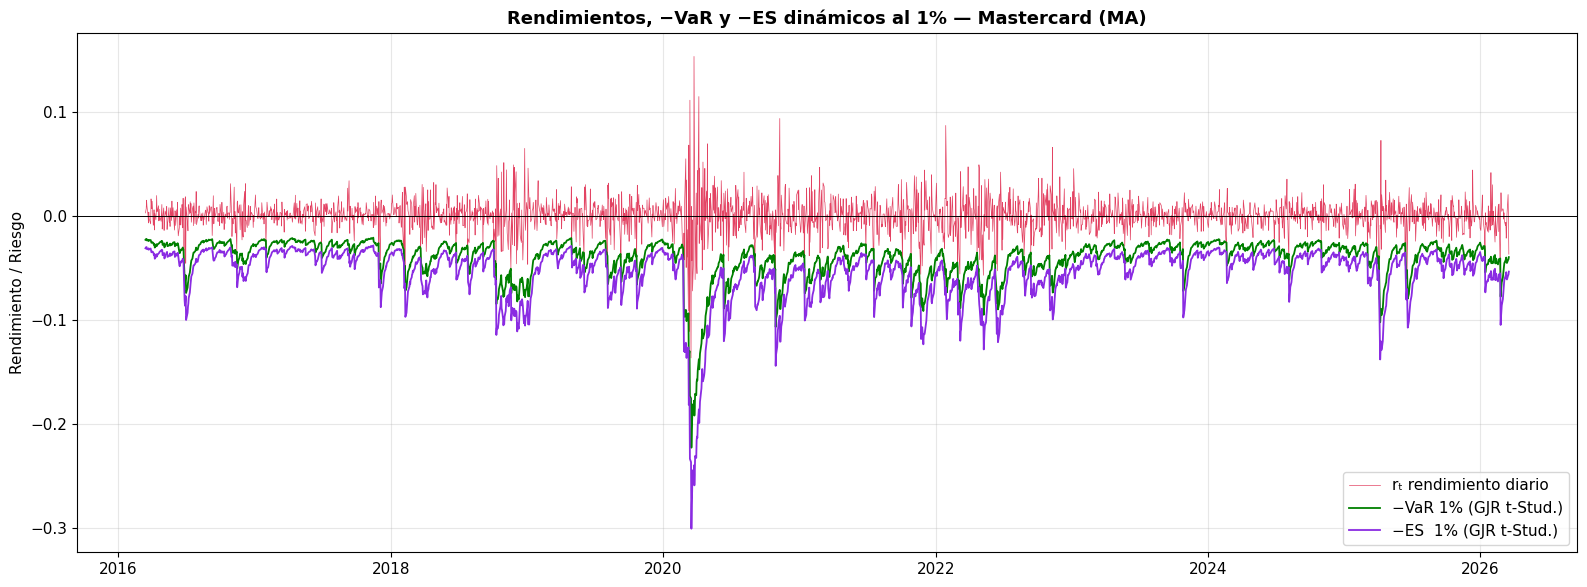

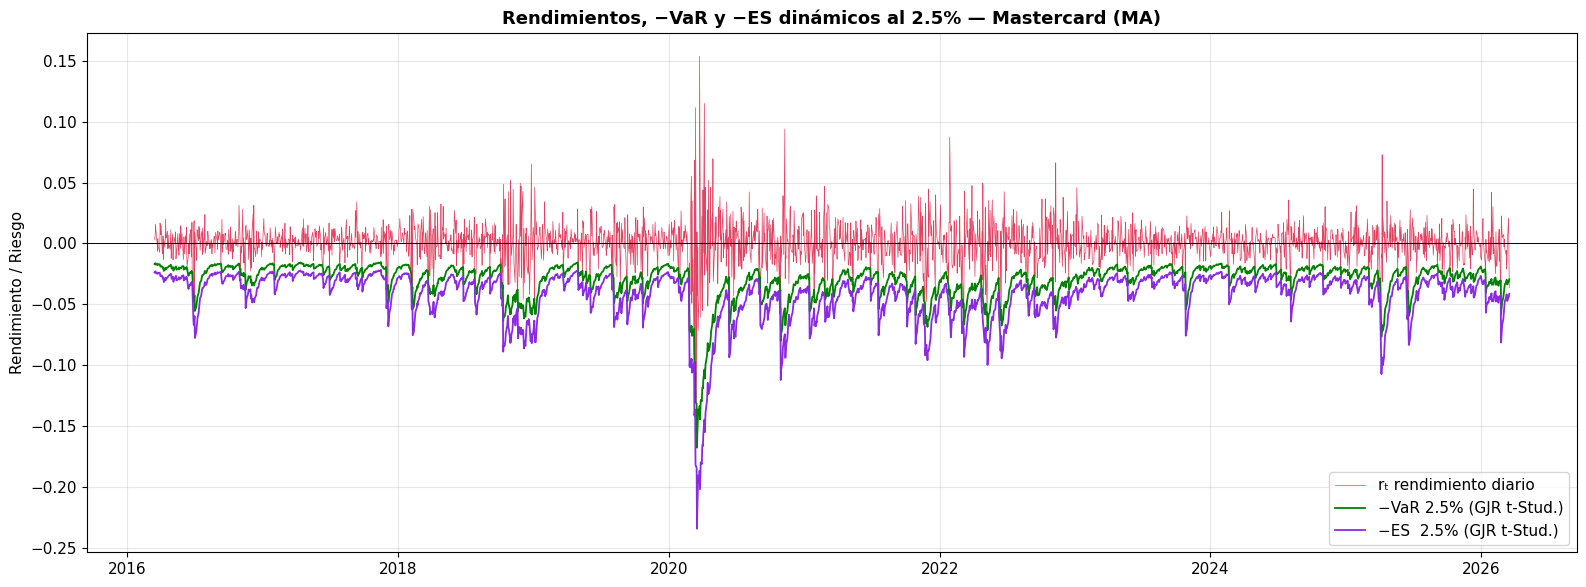


💡 En el gráfico:
  • Línea ROJA: rendimiento diario rₜ
  • Línea VERDE: −VaR dinámico → el nivel a partir del cual hay violación
  • Línea VIOLETA: −ES dinámico → más conservador que el VaR
  • Cuando la línea roja cae POR DEBAJO de la verde → VIOLACIÓN del VaR
  • Durante el COVID (2020) verás picos enormes en las líneas de riesgo


In [17]:
if 'vol_cond_t' not in G:
    print('⚠️  Ejecuta las celdas anteriores primero.')
else:
    df      = G['df']
    r       = df['r']
    mu_r    = G['mu_r']
    dof     = G['dof']
    vol_gjr = G['vol_cond_t']   # σₜ condicional diaria del GJR
    idx_cv  = vol_gjr.index
    r_al    = r.reindex(idx_cv)
    name    = G['name']
    ticker  = G['ticker']

    # Fórmulas exactas(Gretl líneas 229–240)
    def dyn_var_es(vol_series, tau, dof, mu):
        t_q  = t_dist.ppf(tau, df=dof)
        fd_t = t_dist.pdf(t_q, df=dof)
        scale = vol_series * np.sqrt((dof-2)/dof)
        VaR = -mu - scale * t_q
        ES  = -mu + scale * (1/tau) * (1/(dof-1)) * (dof + t_q**2) * fd_t
        return VaR, ES

    VaR_d_01,  ES_d_01  = dyn_var_es(vol_gjr, 0.01,  dof, mu_r)
    VaR_d_025, ES_d_025 = dyn_var_es(vol_gjr, 0.025, dof, mu_r)

    G['VaR_d_01']  = VaR_d_01
    G['ES_d_01']   = ES_d_01
    G['VaR_d_025'] = VaR_d_025
    G['ES_d_025']  = ES_d_025
    G['r_al']      = r_al

    for tau_v, VaR_d, ES_d, tlabel in [
        (0.01,  VaR_d_01,  ES_d_01,  '1%'),
        (0.025, VaR_d_025, ES_d_025, '2.5%')]:

        # Gretl: N_VaR = -VaR_P_t_tau_d  (negativo para graficar con los rendimientos)
        N_VaR = -VaR_d
        N_ES  = -ES_d

        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(r_al.index, r_al.values,   color='crimson',   lw=0.5, alpha=0.8, label='rₜ rendimiento diario')
        ax.plot(N_VaR.index, N_VaR.values, color='green',     lw=1.3, label=f'−VaR {tlabel} (GJR t-Stud.)')
        ax.plot(N_ES.index,  N_ES.values,  color='blueviolet',lw=1.3, label=f'−ES  {tlabel} (GJR t-Stud.)')
        ax.axhline(0, color='black', lw=0.7)
        ax.set_title(f'Rendimientos, −VaR y −ES dinámicos al {tlabel} — {name} ({ticker})',
                     fontweight='bold', fontsize=13)
        ax.set_ylabel('Rendimiento / Riesgo')
        ax.legend(loc='lower right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()

    print('\n💡 En el gráfico:')
    print('  • Línea ROJA: rendimiento diario rₜ')
    print('  • Línea VERDE: −VaR dinámico → el nivel a partir del cual hay violación')
    print('  • Línea VIOLETA: −ES dinámico → más conservador que el VaR')
    print('  • Cuando la línea roja cae POR DEBAJO de la verde → VIOLACIÓN del VaR')
    print('  • Durante el COVID (2020) verás picos enormes en las líneas de riesgo')

## VaR y ES para fechas concretas
  
Calcula el riesgo para el **2020-03-16** (lunes negro del COVID) y para otras fechas.

> Introduce las fechas que quieras analizar.

In [19]:
if 'VaR_d_01' not in G:
    print('⚠️  Ejecuta la Celda 7 primero.')
else:
    VaR_d_01 = G['VaR_d_01']
    ES_d_01  = G['ES_d_01']
    r_al     = G['r_al']
    dof      = G['dof']
    mu_r     = G['mu_r']

    date1_w = widgets.Text(value='2020-03-16', description='Fecha 1:',
                           layout=widgets.Layout(width='260px'))
    date2_w = widgets.Text(value='2024-09-30', description='Fecha 2:',
                           layout=widgets.Layout(width='260px'))
    tau_w   = widgets.RadioButtons(
        options=[('1%  (τ=0.01)', 0.01), ('2.5% (τ=0.025)', 0.025)],
        value=0.01, description='Nivel τ:'
    )
    btn_fd  = widgets.Button(description='📊 Calcular', button_style='primary',
                             layout=widgets.Layout(width='160px'))
    out_fd  = widgets.Output()

    def on_date_calc(b):
        with out_fd:
            clear_output()
            tau = tau_w.value
            vol_gjr = G['vol_cond_t']

            for ds, label in [(date1_w.value, 'Fecha 1'), (date2_w.value, 'Fecha 2')]:
                try:
                    tgt = pd.to_datetime(ds)
                    # Fecha más cercana disponible (como en Gretl obsnum())
                    idx = vol_gjr.index
                    closest = idx[np.argmin(np.abs(idx - tgt))]
                    sigma_t = vol_gjr.loc[closest]

                    t_q  = t_dist.ppf(tau, df=dof)
                    fd_t = t_dist.pdf(t_q, df=dof)
                    scale = sigma_t * np.sqrt((dof-2)/dof)
                    VaR_t = -mu_r - scale * t_q
                    ES_t  = -mu_r + scale * (1/tau) * (1/(dof-1)) * (dof + t_q**2) * fd_t

                    r_act = r_al.get(closest, np.nan)
                    viol  = '🚨 VIOLACIÓN' if (not np.isnan(r_act) and r_act < -VaR_t) else '✅ Sin violación'

                    print(f'📅 {label}: {ds}  (dato más cercano: {closest.date()})')
                    print(f'   σ condicional GJR-t   : {sigma_t:.6f}')
                    print(f'   VaR ({tau*100:.1f}%) t-Student  : {-VaR_t:.6f}   (valor abs.)')
                    print(f'   ES  ({tau*100:.1f}%) t-Student  : {-ES_t:.6f}   (valor abs.)')
                    if not np.isnan(r_act):
                        print(f'   Rendimiento real        : {r_act:.6f}   → {viol}')
                    print()
                except Exception as e:
                    print(f'❌ Error con {ds}: {e}')

    btn_fd.on_click(on_date_calc)
    display(HTML('<h4>Introduce las fechas ( usa 2020-03-16 para el COVID):</h4>'))
    display(widgets.HBox([date1_w, date2_w]))
    display(widgets.HBox([tau_w, btn_fd]))
    display(out_fd)

Output()

##  Test de Kupiec (Backtesting · Número de Violaciones)


```
LR = -2*ln(tau^n_viol * (1-tau)^(T-n_viol)) + 2*ln(r_viol^n_viol * (1-r_viol)^(T-n_viol))
pval_LR = 1 - cdf(c, 1, LR)
```

### ¿Qué es el Test de Kupiec?
Comprueba si el **porcentaje real de violaciones** es estadísticamente igual a τ.

- **H₀**: p_violaciones = τ (el modelo es correcto)
- **H₁**: p_violaciones ≠ τ (el modelo falla)
- Si **p-valor < 0.05** → rechazamos H₀ → el modelo no ajusta bien

El estadístico LR sigue una $\chi^2(1)$ bajo H₀.

📋 TABLA 5 — Test de Kupiec · Número de Violaciones
  Total observaciones: T = 2518
  Modelo                           #Viol    % Viol  Esperadas        LR   P-valor
--------------------------------------------------------------------------------
  GJR t-Student (τ=1%)                38  0.015091       25.2   5.70279  0.016938
  GJR t-Student (τ=2.5%)              80  0.031771       63.0   4.36842  0.036611
  Normal estático (τ=1%)              56  0.022240       25.2  28.26441  0.000000
  Normal estático (τ=2.5%)            81  0.032168       63.0   4.87459  0.027255

── Decisión automática (equivalente al printf de Gretl):
  [GJR t-Student (τ=1%)]  ⚠️  RECHAZA H₀ al 5%  (p=0.0169 < 0.05) → el modelo NO ajusta bien
  [GJR t-Student (τ=2.5%)]  ⚠️  RECHAZA H₀ al 5%  (p=0.0366 < 0.05) → el modelo NO ajusta bien
  [Normal estático (τ=1%)]  ❌ RECHAZA H₀ al 1%  (p=0.0000 < 0.01) → el modelo NO ajusta bien
  [Normal estático (τ=2.5%)]  ⚠️  RECHAZA H₀ al 5%  (p=0.0273 < 0.05) → el modelo NO aj

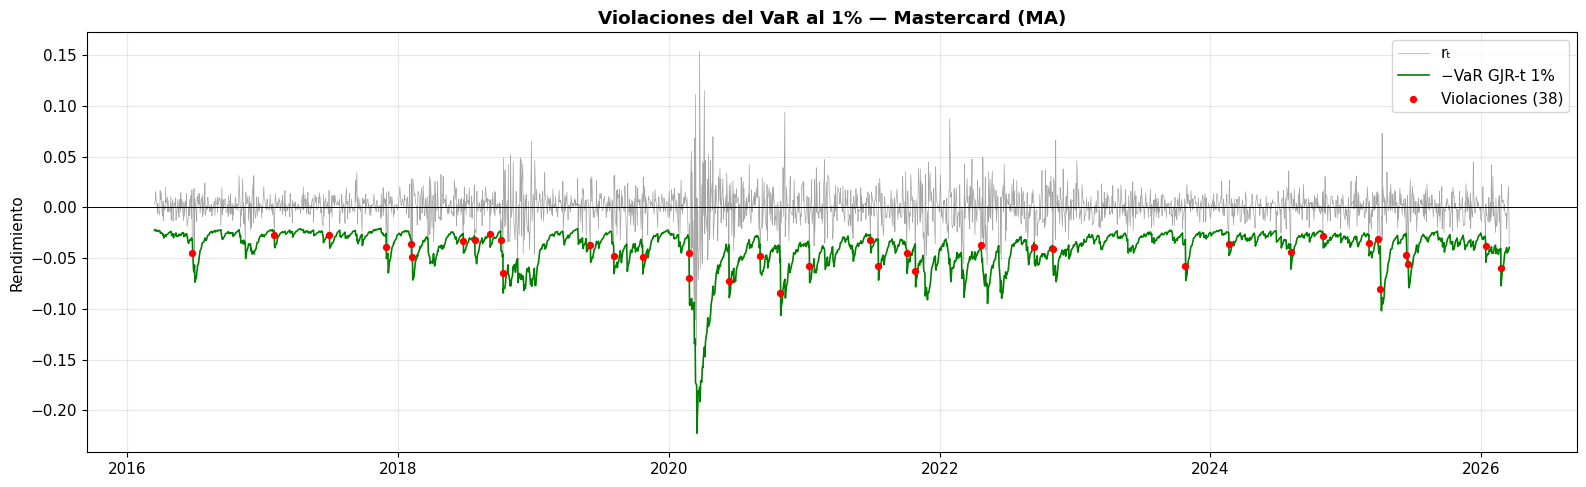


💡 INTERPRETACIÓN:
  • Con τ=1%, lo normal es ~25 violaciones en 2518 días
  • Si hay MUCHAS más → el VaR subestima el riesgo real
  • Si hay MUCHAS menos → el VaR sobreestima el riesgo (modelo demasiado conservador)
  • Las violaciones se agrupan en períodos de crisis → clusters de volatilidad


In [20]:
if 'VaR_d_01' not in G:
    print('⚠️  Ejecuta las celdas anteriores primero.')
else:
    r_al    = G['r_al']
    VaR_d   = G['VaR_d_01']   # VaR dinámico al 1%
    VaR_d25 = G['VaR_d_025']  # VaR dinámico al 2.5%
    sd_r    = G['sd_r']
    mu_r    = G['mu_r']
    dof     = G['dof']
    name    = G['name']
    ticker  = G['ticker']
    T       = len(r_al)

    # ── Función Kupiec (Gretl líneas 272–285) ────────────────────
    def kupiec(n_viol, T, tau):
        """Calcula LR y p-valor del test de Kupiec (cobertura incondicional)"""
        if n_viol == 0 or n_viol == T:
            return np.nan, np.nan
        r_viol = n_viol / T
        # LR = -2*ln(numerator) + 2*ln(denominator)
        # numerator = tau^n * (1-tau)^(T-n)
        # denominator = r_viol^n * (1-r_viol)^(T-n)
        numerator   = tau**n_viol   * (1-tau)**  (T-n_viol)
        denominator = r_viol**n_viol * (1-r_viol)**(T-n_viol)
        LR = -2 * np.log(numerator / denominator)
        pval = 1 - stats.chi2.cdf(LR, df=1)
        return LR, pval

    # ── Modelos a comparar ───────────────────────────────────────
    # VaR Normal estático
    z01  = norm.ppf(0.01)
    z025 = norm.ppf(0.025)
    VaR_N_01  = pd.Series(-mu_r - sd_r * z01,  index=r_al.index)
    VaR_N_025 = pd.Series(-mu_r - sd_r * z025, index=r_al.index)

    modelos_kup = [
        ('GJR t-Student (τ=1%)',  VaR_d,    0.01),
        ('GJR t-Student (τ=2.5%)',VaR_d25,  0.025),
        ('Normal estático (τ=1%)', VaR_N_01,  0.01),
        ('Normal estático (τ=2.5%)',VaR_N_025,0.025),
    ]

    print(f'📋 TABLA 5 — Test de Kupiec · Número de Violaciones')
    print(f'  Total observaciones: T = {T}')
    print('='*80)
    print(f'  {"Modelo":<30}{"#Viol":>8}{"% Viol":>10}{"Esperadas":>11}{"LR":>10}{"P-valor":>10}')
    print('-'*80)

    for lab, VaR_s, tau in modelos_kup:
        # Gretl: smpl r_my_v <= N_VaR --restrict  → n_viol = $nobs
        n_viol = (r_al < -VaR_s).sum()
        pct    = n_viol / T
        esp    = T * tau
        LR, pv = kupiec(n_viol, T, tau)
        pv_str = f'{pv:.6f}' if not np.isnan(pv) else '   —   '
        LR_str = f'{LR:.5f}' if not np.isnan(LR) else '   —   '
        print(f'  {lab:<30}{n_viol:>8}{pct:>10.6f}{esp:>11.1f}{LR_str:>10}{pv_str:>10}')

    print('='*80)

    # Decisión automática (equivale al bloque if/elif de Gretl)
    print('\n── Decisión automática (equivalente al printf de Gretl):')
    for lab, VaR_s, tau in modelos_kup:
        n_viol = (r_al < -VaR_s).sum()
        LR, pv = kupiec(n_viol, T, tau)
        if np.isnan(pv):
            continue
        print(f'  [{lab}]', end='  ')
        # Gretl: if pval_LR <= 0.01 → rechaza; elif <= 0.05 → rechaza; else → no rechaza
        if pv <= 0.01:
            print(f'❌ RECHAZA H₀ al 1%  (p={pv:.4f} < 0.01) → el modelo NO ajusta bien')
        elif pv <= 0.05:
            print(f'⚠️  RECHAZA H₀ al 5%  (p={pv:.4f} < 0.05) → el modelo NO ajusta bien')
        else:
            print(f'✅ No hay evidencia para rechazar el modelo  (p={pv:.4f} ≥ 0.05)')

    # ── Gráfico de violaciones ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(r_al.index, r_al.values, color='gray', lw=0.5, alpha=0.7, label='rₜ')
    ax.plot((-VaR_d).index, (-VaR_d).values, color='green', lw=1.2,
            label=f'−VaR GJR-t 1%')
    mask_v = r_al < -VaR_d
    n_v = mask_v.sum()
    ax.scatter(r_al.index[mask_v], r_al.values[mask_v],
               color='red', s=18, zorder=5, label=f'Violaciones ({n_v})')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(f'Violaciones del VaR al 1% — {name} ({ticker})', fontweight='bold')
    ax.set_ylabel('Rendimiento')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    print(f'\n💡 INTERPRETACIÓN:')
    print(f'  • Con τ=1%, lo normal es ~{T*0.01:.0f} violaciones en {T} días')
    print(f'  • Si hay MUCHAS más → el VaR subestima el riesgo real')
    print(f'  • Si hay MUCHAS menos → el VaR sobreestima el riesgo (modelo demasiado conservador)')
    print(f'  • Las violaciones se agrupan en períodos de crisis → clusters de volatilidad')

##  Dashboard Final

Resumen visual completo de todo el análisis.

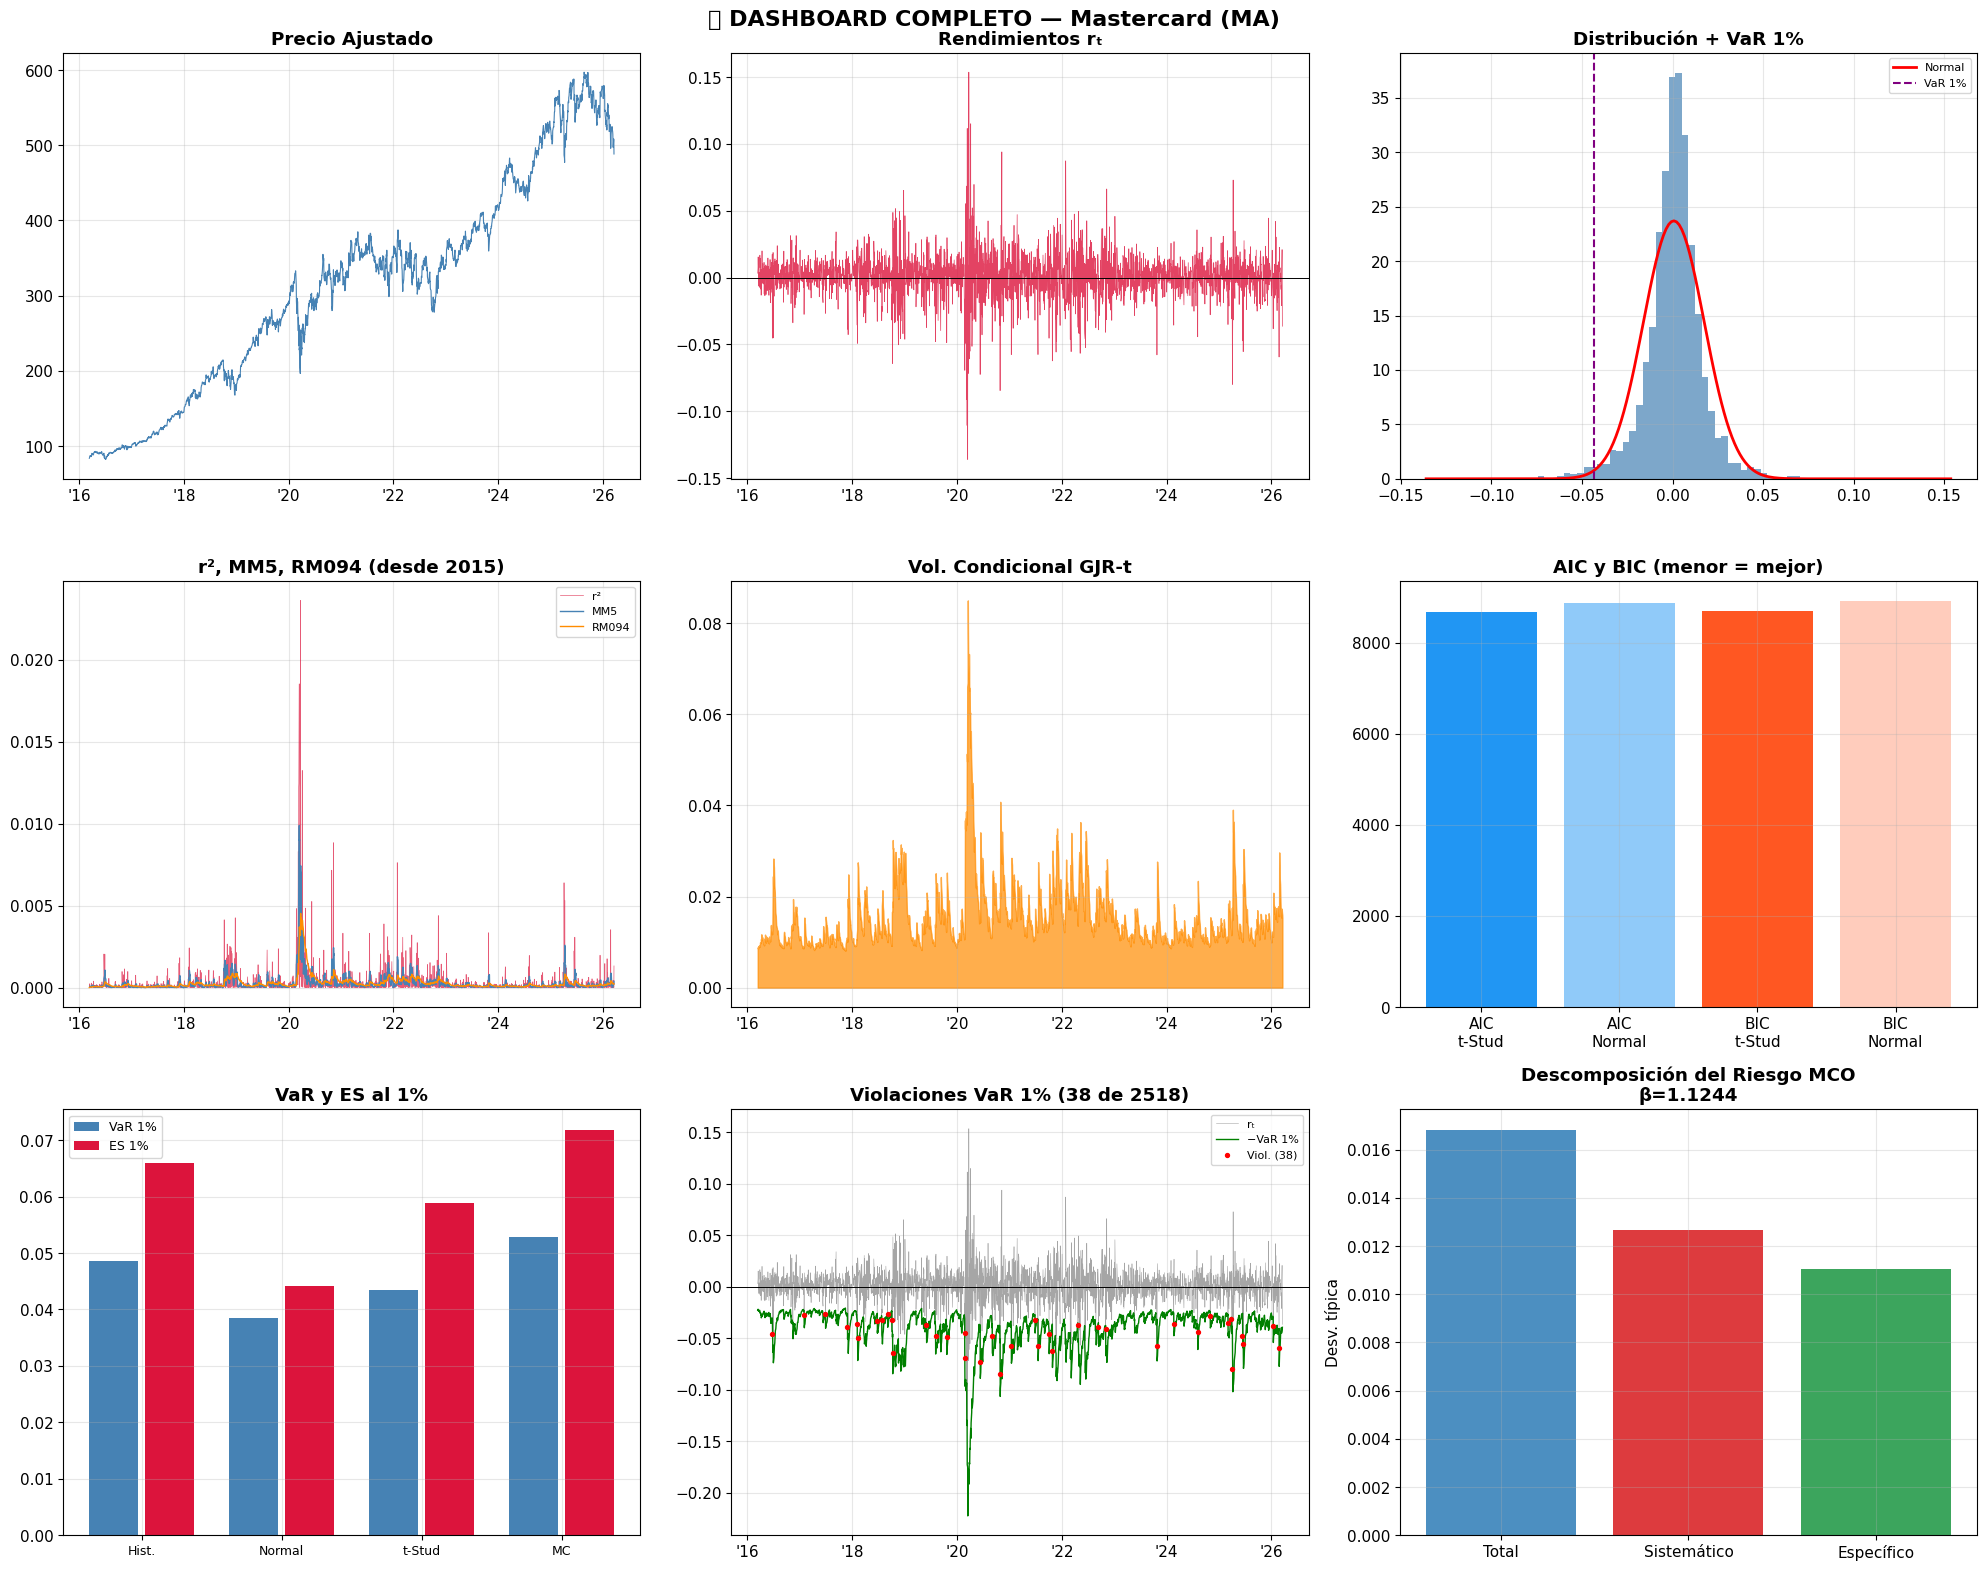


✅ ¡Análisis completo!
   Empresa analizada : Mastercard (MA)
   Modelo preferido  : t-Student (mayor Llik, menor AIC/BIC)
   VaR 1%  t-Student : 0.043501
   ES  1%  t-Student : 0.058926
   Violaciones VaR 1%: 38 de 2518 (1.509%)


In [21]:
if 'RES' not in G:
    print('⚠️  Ejecuta todas las celdas anteriores primero.')
else:
    df      = G['df']
    r       = df['r']
    pt      = G['pt']
    pn      = G['pn']
    RES     = G['RES']
    vol_gjr = G['vol_cond_t']
    VaR_d   = G['VaR_d_01']
    name    = G['name']
    ticker  = G['ticker']
    r_al    = G['r_al']

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(f'📊 DASHBOARD COMPLETO — {name} ({ticker})',
                 fontsize=16, fontweight='bold')

    # 1. Precio
    ax1 = fig.add_subplot(3, 3, 1)
    ax1.plot(df.index, df['price'], color='steelblue', lw=0.8)
    ax1.set_title('Precio Ajustado', fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 2. Rendimientos
    ax2 = fig.add_subplot(3, 3, 2)
    ax2.plot(df.index, r, color='crimson', lw=0.5, alpha=0.8)
    ax2.axhline(0, color='black', lw=0.7)
    ax2.set_title('Rendimientos rₜ', fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 3. Histograma
    ax3 = fig.add_subplot(3, 3, 3)
    ax3.hist(r, bins=80, color='steelblue', alpha=0.7, density=True)
    xr = np.linspace(r.min(), r.max(), 200)
    ax3.plot(xr, norm.pdf(xr, r.mean(), r.std()), 'r-', lw=2, label='Normal')
    ax3.axvline(-RES[0.01]['VaR_Pt'], color='purple', ls='--', lw=1.5, label='VaR 1%')
    ax3.set_title('Distribución + VaR 1%', fontweight='bold')
    ax3.legend(fontsize=8)

    # 4. r², MM5, RM094
    ax4 = fig.add_subplot(3, 3, 4)
    mask = df.index >= '2015-01-01'
    ax4.plot(df.index[mask], df['sq_r'][mask],  color='crimson',   lw=0.5, alpha=0.7, label='r²')
    ax4.plot(df.index[mask], df['MM5'][mask],   color='steelblue', lw=1,   label='MM5')
    ax4.plot(df.index[mask], df['RM094'][mask], color='darkorange',lw=1,   label='RM094')
    ax4.set_title('r², MM5, RM094 (desde 2015)', fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 5. Volatilidad condicional GJR
    ax5 = fig.add_subplot(3, 3, 5)
    ax5.fill_between(vol_gjr.index, vol_gjr.values, color='darkorange', alpha=0.7)
    ax5.set_title('Vol. Condicional GJR-t', fontweight='bold')
    ax5.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 6. AIC/BIC comparativo
    ax6 = fig.add_subplot(3, 3, 6)
    cats = ['AIC\nt-Stud', 'AIC\nNormal', 'BIC\nt-Stud', 'BIC\nNormal']
    vals = [pt['aic'], pn['aic'], pt['bic'], pn['bic']]
    colors_bar = ['#2196F3', '#90CAF9', '#FF5722', '#FFCCBC']
    ax6.bar(cats, vals, color=colors_bar)
    ax6.set_title('AIC y BIC (menor = mejor)', fontweight='bold')

    # 7. VaR/ES 1% por método
    ax7 = fig.add_subplot(3, 3, 7)
    mets = ['Hist.', 'Normal', 't-Stud', 'MC']
    vs7  = [RES[0.01]['VaR_H'], RES[0.01]['VaR_PN'], RES[0.01]['VaR_Pt'], RES[0.01]['VaR_MC']]
    es7  = [RES[0.01]['ES_H'],  RES[0.01]['ES_PN'],  RES[0.01]['ES_Pt'],  RES[0.01]['ES_MC']]
    x7   = np.arange(4)
    ax7.bar(x7-0.2, vs7, 0.35, label='VaR 1%', color='steelblue')
    ax7.bar(x7+0.2, es7, 0.35, label='ES 1%',  color='crimson')
    ax7.set_xticks(x7); ax7.set_xticklabels(mets, fontsize=9)
    ax7.set_title('VaR y ES al 1%', fontweight='bold')
    ax7.legend(fontsize=9)

    # 8. Rendimientos + -VaR dinámico + violaciones
    ax8 = fig.add_subplot(3, 3, 8)
    ax8.plot(r_al.index, r_al.values, color='gray', lw=0.4, alpha=0.7, label='rₜ')
    ax8.plot((-VaR_d).index, (-VaR_d).values, color='green', lw=1, label='−VaR 1%')
    mask_v = r_al < -VaR_d
    ax8.scatter(r_al.index[mask_v], r_al.values[mask_v], color='red', s=8, zorder=5,
                label=f'Viol. ({mask_v.sum()})')
    ax8.axhline(0, color='black', lw=0.7)
    ax8.set_title(f'Violaciones VaR 1% ({mask_v.sum()} de {len(r_al)})', fontweight='bold')
    ax8.legend(fontsize=8)
    ax8.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 9. Riesgos MCO
    ax9 = fig.add_subplot(3, 3, 9)
    if 'MCO' in G:
        MCO = G['MCO']
        yhat  = MCO.fittedvalues
        resid = MCO.resid
        riesgos = [r.std(), yhat.std(), resid.std()]
        ax9.bar(['Total', 'Sistemático', 'Específico'], riesgos,
                color=['#2c7bb6', '#d7191c', '#1a9641'], alpha=0.85)
        ax9.set_title(f'Descomposición del Riesgo MCO\nβ={G["beta"]:.4f}', fontweight='bold')
        ax9.set_ylabel('Desv. típica')
    else:
        ax9.text(0.5, 0.5, 'Ejecuta\nBloque 1', ha='center', va='center', fontsize=12)
        ax9.set_title('Riesgo MCO')

    plt.tight_layout()
    plt.show()

    print('\n✅ ¡Análisis completo!')
    print(f'   Empresa analizada : {name} ({ticker})')
    print(f'   Modelo preferido  : t-Student (mayor Llik, menor AIC/BIC)')
    print(f'   VaR 1%  t-Student : {RES[0.01]["VaR_Pt"]:.6f}')
    print(f'   ES  1%  t-Student : {RES[0.01]["ES_Pt"]:.6f}')
    print(f'   Violaciones VaR 1%: {mask_v.sum()} de {len(r_al)} ({mask_v.sum()/len(r_al)*100:.3f}%)')

In [ ]:
#programado con claude ; supervisado personalmente.
